# Section 1: Clean the dataset  

## Data Import & Struture Review

### Import Libraries

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn.metrics as metrics
import statsmodels.api as sm
from scipy.stats import ttest_ind


### Import Dataset

In [135]:
df_2023 = pd.read_csv("/Users/rosie/Documents/BUSA8000_DOCUMENTS/BUSA8000_Group Assignment/2023.csv", encoding="ISO-8859-1", low_memory=False)
df_2024 = pd.read_csv("/Users/rosie/Documents/BUSA8000_DOCUMENTS/BUSA8000_Group Assignment/2024.csv", encoding="ISO-8859-1", low_memory=False)
df_merge = df = pd.concat([df_2023, df_2024], axis=0, join='outer', ignore_index=True)

df_merge.head()

,accounting_date,fiscal_year,fiscal_month,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,...,value_price_adjustment,currency,item_source_class,invoice_number,line_number,invoice_date,customer_order_number,order_date,dss_update_time,customer_order_number.1
0,20230523.0,2023.0,11.0,101.0,598961420.0,NaN,NaN,LMP,LMP01008,LMP01,...,0.0,AUD,NaN,2224423.0,1.0,20230523.0,5743886.0,20230523.0,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988382 entries, 0 to 1988381
Data columns (total 39 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   accounting_date           object 
 1   fiscal_year               float64
 2   fiscal_month              float64
 3   company_code              object 
 4   customer_code             float64
 5   customer_district_code    object 
 6   item_code                 object 
 7   business_area_code        object 
 8   item_group_code           object 
 9   item_class_code           object 
 10  item_type                 object 
 11  bonus_group_code          object 
 12  environment_group_code    object 
 13  technology_group_code     object 
 14  commission_group_code     object 
 15  reporting_classification  object 
 16  light_source              object 
 17  warehouse_code            object 
 18  abc_class_code            object 
 19  abc_class_volume          object 
 20  business_chain_l1_code  

## Data Type & Formart Correction

In [137]:
# Dropping usable columns
unusable_column = ['contact_method_code', 'market_segment', 'item_source_class', 'dss_update_time', 'customer_order_number.1']
df_merge = df_merge.drop(unusable_column, axis = 1)

# Datetime format conversion
for col in ['accounting_date', 'invoice_date', 'order_date']:
    df_merge[col] = df_merge[col].astype(str).str.replace('.0', '', regex=False)
    df_merge[col] = pd.to_datetime(df_merge[col], format='%Y%m%d', errors='coerce')

# Convert dtype in 'fiscal_year', 'fiscal_month' columns into int64
df_merge['fiscal_year'] = df_merge['fiscal_year'].astype('Int64')
df_merge['fiscal_month'] = df_merge['fiscal_month'].astype('Int64')

# Convert value_sales column into numeric
df_merge['value_sales'] = pd.to_numeric(df_merge['value_sales'], errors='coerce')

df_merge['customer_order_number'] = df_merge['customer_order_number'].astype('Int64').astype('str')
df_merge['customer_code'] = df_merge['customer_code'].astype('Int64').astype('str')
df_merge['line_number'] = df_merge['line_number'].astype('Int64').astype('str')

df_merge.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988382 entries, 0 to 1988381
Data columns (total 34 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   accounting_date           datetime64[ns]
 1   fiscal_year               Int64         
 2   fiscal_month              Int64         
 3   company_code              object        
 4   customer_code             object        
 5   customer_district_code    object        
 6   item_code                 object        
 7   business_area_code        object        
 8   item_group_code           object        
 9   item_class_code           object        
 10  item_type                 object        
 11  bonus_group_code          object        
 12  environment_group_code    object        
 13  technology_group_code     object        
 14  commission_group_code     object        
 15  reporting_classification  object        
 16  light_source              object        
 17  warehous

In [138]:
df_merge = df_merge.sort_values(by='accounting_date')
df_merge.shape

(1988382, 34)

## Check Duplicated 

In [139]:
df_merge.duplicated().sum()

np.int64(8222)

In [140]:
df_merge.dropna(how='all', inplace=True)
df_merge.drop_duplicates(inplace=True)

df_merge.shape

(1980160, 34)

## Check & Handle Missing Values

In [141]:
df_merge.isna().sum()

accounting_date             4205
fiscal_year                   31
fiscal_month                  27
company_code                  30
customer_code                  0
customer_district_code        43
item_code                     45
business_area_code            35
item_group_code               32
item_class_code               33
item_type                     31
bonus_group_code              30
environment_group_code        30
technology_group_code         35
commission_group_code         31
reporting_classification      36
light_source                  32
warehouse_code                31
abc_class_code                30
abc_class_volume              30
business_chain_l1_code        31
business_chain_l1_name        35
salesperson_code              33
order_type_code               29
value_sales                   30
value_cost                    30
value_quantity                30
value_price_adjustment        81
currency                      19
invoice_number                20
line_numbe

In [142]:
df_merge.dropna(inplace=True)
df_merge.isna().sum()

accounting_date             0
fiscal_year                 0
fiscal_month                0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             0
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      0
salesperson_code            0
order_type_code             0
value_sales                 0
value_cost                  0
value_quantity              0
value_price_adjustment      0
currency                    0
invoice_number              0
line_number                 0
invoice_date                0
customer_order_number       0
order_date

In [143]:
df_merge.shape

(1974569, 34)

## Check Unique Values

In [144]:
numeric_columns = ['value_sales', 'value_cost', 'value_quantity']

categorical_columns = [
    'company_code', 'customer_code', 'customer_district_code', 'item_code', 'business_area_code', 
    'item_group_code', 'item_class_code', 'item_type', 'bonus_group_code', 
    'environment_group_code', 'technology_group_code', 'commission_group_code', 
    'reporting_classification', 'light_source', 'warehouse_code', 
    'abc_class_code', 'abc_class_volume', 'business_chain_l1_code', 'business_chain_l1_name', 
    'salesperson_code', 'order_type_code', 'value_price_adjustment','currency', 
    'invoice_number', 'line_number', 'customer_order_number'
]

In [145]:
for column in categorical_columns:
    df_merge[column] = df_merge[column].astype(str).str.strip()

In [146]:
# Get the number of unique values for each column
df_merge.nunique()

accounting_date                542
fiscal_year                      3
fiscal_month                    13
company_code                    16
customer_code                 3658
customer_district_code          19
item_code                    34423
business_area_code              28
item_group_code                615
item_class_code                204
item_type                       19
bonus_group_code                 2
environment_group_code           9
technology_group_code          103
commission_group_code            3
reporting_classification         2
light_source                     5
warehouse_code                  59
abc_class_code                  10
abc_class_volume                10
business_chain_l1_code          49
business_chain_l1_name          45
salesperson_code               272
order_type_code                 38
value_sales                 124995
value_cost                  323766
value_quantity                2289
value_price_adjustment           2
currency            

### accounting_date 

In [147]:
unique_accounting_date = df_merge['accounting_date'].unique()
print(unique_accounting_date)


<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-05 00:00:00', '2023-01-06 00:00:00', '2023-01-07 00:00:00',
 '2023-01-09 00:00:00', '2023-01-10 00:00:00', '2023-01-11 00:00:00',
 '2023-01-12 00:00:00',
 ...
 '2024-12-17 00:00:00', '2024-12-18 00:00:00', '2024-12-19 00:00:00',
 '2024-12-20 00:00:00', '2024-12-22 00:00:00', '2024-12-23 00:00:00',
 '2024-12-24 00:00:00', '2024-12-27 00:00:00', '2024-12-30 00:00:00',
 '2024-12-31 00:00:00']
Length: 542, dtype: datetime64[ns]


In [148]:
# Check frequency
df_merge['accounting_date'].value_counts().get('2023-02-29 00:00:00', 0)

0

### fiscal_year 

In [149]:
unique_fiscal_year = df_merge['fiscal_year'].unique()
print(unique_fiscal_year)

<IntegerArray>
[2023, 2024, 2025]
Length: 3, dtype: Int64


### fiscal_month

In [150]:
unique_fiscal_month = df_merge['fiscal_month'].unique()
print(unique_fiscal_month)

<IntegerArray>
[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 13]
Length: 13, dtype: Int64


In [151]:
df_merge = df_merge[df_merge['fiscal_month'] != 13] 

In [152]:
unique_fiscal_month = df_merge['fiscal_month'].unique()
print(unique_fiscal_month)

<IntegerArray>
[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
Length: 12, dtype: Int64


### company_code 

In [153]:
unique_company_code = df_merge['company_code'].unique()
print(unique_company_code)

['205.0' '101.0' '220.0' '510.0' '950.0' '100.0' '140.0' '240.0' '170.0'
 '205' '101' '950' '240' '120' 'Na' '100']


In [154]:
df_merge['company_code'] = (
    df_merge['company_code']
    .astype(str)          
    .str.strip()          
    .str.replace(r'\.0$', '', regex=True) 
)

df_merge['company_code'] = df_merge['company_code'].replace(['Na'], np.nan)
df_merge['company_code'].isna().sum()

np.int64(1)

In [155]:
df_merge = df_merge.dropna(subset=['company_code'])

In [156]:
unique_company_code = df_merge['company_code'].unique()
print(unique_company_code)

['205' '101' '220' '510' '950' '100' '140' '240' '170' '120']


### custome_code

In [157]:
unique_customer_code = df_merge['customer_code'].unique()
print(unique_customer_code)

['710000400' '500000200' '500400200' ... '418600200' '400380200'
 '1449800400']


In [158]:
# Check frequency
df_merge['customer_code'].value_counts().get('<NA>', 0)

np.int64(115950)

In [159]:
df_merge['customer_code'] = df_merge['customer_code'].replace(['<NA>'], np.nan)
df_merge['customer_code'].isna().sum()

np.int64(115950)

In [160]:
df_merge['customer_code'] = df_merge['customer_code'].fillna('Unknown')
df_merge['customer_code'].isna().sum()

np.int64(0)

### customer_distric_code

In [161]:
unique_customer_district_code = df_merge['customer_district_code'].unique()
print(unique_customer_district_code)

# There isn't a 100 value in metadata

['300' '200' '400' '210' '600' '310' '500' '510' '710' '410' '720' '535'
 '540' '530' '520' 'Na' '545' 'na' '100']


In [162]:
# Check frequency
df_merge['customer_district_code'].value_counts().get('100', 0)

np.int64(6)

In [163]:
# Drop rows where customer_district_code is 100
df_merge = df_merge[~df_merge['customer_district_code'].isin(['100'])]

In [164]:
# Replace 'Na'/'na' with NaN and count missing entries
df_merge['customer_district_code'] = df_merge['customer_district_code'].replace(['Na', 'na'], np.nan)
df_merge['customer_district_code'].isna().sum()

np.int64(5)

In [165]:
# Drop rows with missing values in customer_district_code column
df_merge = df_merge.dropna(subset=['customer_district_code'])

In [166]:
unique_customer_district_code = df_merge['customer_district_code'].unique()
print(unique_customer_district_code)

['300' '200' '400' '210' '600' '310' '500' '510' '710' '410' '720' '535'
 '540' '530' '520' '545']


### item_code 

In [167]:
unique_item_code = df_merge['item_code'].unique()
print(unique_item_code)

['24893' '25591' '20436' ... 'DT274883224ED9W' 'DT2063112132W' 'DT2748990']


### business_area_code

In [168]:
unique_business_area_code = df_merge['business_area_code'].unique()
print(unique_business_area_code)

# Some values need to correct with values from metadata: 
# 945 -> IAE , 920 -> FLD , 960 -> SAE , 930 -> RWY
# 999 -> OTH , 970 -> LMP , 940 -> IAI

['SUR' 'LMP' 'FLD' 'COM' 'URB' 'LCP' 'OTH' 'DLT' 'PEN' 'TRO' 'RWY' 'SAE'
 'TAL' '960' '970' 'HLB' '980' 'IAI' '950' '985' '999' '920' '940' '910'
 'EXL' '945' 'IAE' '930']


In [169]:
# Replace business_area_code with correct values from metadata 
df_merge['business_area_code'] = df_merge['business_area_code'].replace('945', 'IAE')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('920', 'FLD')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('960', 'SAE')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('930', 'RWY')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('999', 'OTH')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('970', 'LMP')
df_merge['business_area_code'] = df_merge['business_area_code'].replace('940', 'IAI')

In [170]:
unique_business_area_code = df_merge['business_area_code'].unique()
print(unique_business_area_code)

['SUR' 'LMP' 'FLD' 'COM' 'URB' 'LCP' 'OTH' 'DLT' 'PEN' 'TRO' 'RWY' 'SAE'
 'TAL' 'HLB' '980' 'IAI' '950' '985' '910' 'EXL' 'IAE']


### item_group_code 

In [171]:
unique_item_group_code = df_merge['item_group_code'].unique()
print(unique_item_group_code)

['SUR06001' 'SUR10001' 'SUR02001' 'LMP01004' 'SUR04001' 'SUR12001'
 'FLD04002' 'SUR11001' 'COM99001' 'URB04001' 'LCP01001' 'LMP01003'
 'LMP04009' 'LMP01001' 'SUR05001' 'LMP04008' 'LMP03015' 'SUR01001'
 'COM90001' 'FLD04001' 'LMP04010' 'LMP05022' '999' 'SUR03001' 'LMP01007'
 'LMP04004' 'URB02001' 'LMP05002' 'LMP05015' 'LMP03003' 'LMP01005'
 'URB04002' 'DLT02002' 'DLT01002' 'LMP02001' 'DLT04003' 'LMP11001'
 'LMP01002' 'COM03002' 'DLT03003' 'LMP05012' 'SUR08001' 'LMP05020'
 'LMP01006' 'PEN01001' 'PEN01003' 'LMP05014' 'URB05002' 'LMP01009'
 'LMP05017' 'PEN04001' 'URB90001' 'LMP03002' 'LMP04002' 'LMP05025'
 'LMP04006' 'SUR90001' 'LMP03006' 'DLT90001' 'LMP05027' 'LMP03005'
 'TRO02001' 'FLD02002' 'LMP06003' 'LMP01008' 'LMP04013' 'LMP04017'
 'SUR07002' 'FLD03002' 'SUR14001' 'LMP06001' 'LMP01010' 'LMP09001'
 'COM08001' 'LMP03001' 'LMP04012' 'LMP03009' 'RWY01001' 'LMP04001'
 'LMP06004' 'LMP03011' 'SAE02002' 'RWY02001' 'TAL90001' 'LMP04018'
 'LMP05008' 'COM06001' 'LMP06005' 'COM14001' '530' 'COM1

### item_class_code

In [172]:
unique_item_class_code = df_merge['item_class_code'].unique()
print(unique_item_class_code)

['SUR06' 'SUR10' 'SUR02' 'LMP01' 'SUR04' 'SUR12' 'FLD04' 'SUR11' 'COM99'
 'URB04' 'LCP01' 'LMP04' 'SUR05' 'LMP03' 'SUR01' 'COM90' 'LMP05' '14001'
 'SUR03' 'URB02' 'DLT02' 'DLT01' 'LMP02' 'DLT04' 'LMP11' 'COM03' 'DLT03'
 'SUR08' 'PEN01' 'URB05' 'PEN04' 'URB90' 'SUR90' 'DLT90' 'TRO02' 'FLD02'
 'LMP06' 'SUR07' 'FLD03' 'SUR14' 'LMP09' 'COM08' 'RWY01' 'SAE02' 'RWY02'
 'TAL90' 'COM06' 'COM14' '8001' 'COM10' '16137' 'FLD01' 'HLB02' 'LMP07'
 'RWY90' '16133' '2515' 'TAL99' 'SUR09' 'SUR80' 'IAI10' 'COM17' 'COM01'
 'SUR13' 'HLB01' 'LMP10' 'TAL01' '2501' 'COM13' 'TAL07' 'SAE01' '2516'
 'COM16' 'TRO03' '2504' 'SUR99' 'URB03' 'COM02' '16135' 'TAL02' 'COM05'
 'FLD90' '17100' '16131' 'TAL08' '5003' '2514' 'COM12' '2012' 'LMP12'
 'SAE80' 'HLB90' '2005' '6003' '2511' 'TRO90' '3002' '2003' 'TAL05'
 'URB01' 'COM09' '6001' 'EXL06' 'URB99' '2507' '2604' 'HLB99' '2509'
 '4504' 'PEN08' 'SAE90' '2510' 'COM15' 'IAE05' '2512' '2006' 'TAL04'
 '2513' 'COM04' '3006' '11103' '15999' '2508' '16134' 'EXL90' '2011'
 'P

### item_type

In [173]:
unique_item_type = df_merge['item_type'].unique()
print(unique_item_type)

['7.0' '5.0' '9.0' '6.0' '1.0' '4.0' '8.0' '3.0' '2.0' '5' '7' '9' '6' '4'
 '1' '8' '2' '3' 'na']


In [174]:
df_merge['item_type'] = (
    df_merge['item_type']
    .astype(str)          
    .str.strip()          
    .str.replace(r'\.0$', '', regex=True) 
)

# Replace 'na' with NaN and count missing entries
df_merge['item_type'] = df_merge['item_type'].replace(['na'], np.nan)
df_merge['item_type'].isna().sum()

np.int64(1)

In [175]:
# Drop rows with missing values in item_type column
df_merge = df_merge.dropna(subset=['item_type'])

In [176]:
unique_item_type = df_merge['item_type'].unique()
print(unique_item_type)

['7' '5' '9' '6' '1' '4' '8' '3' '2']


### bonus_group_code 

In [177]:
unique_bonus_group_code = df_merge['bonus_group_code'].unique()
print(unique_bonus_group_code)

['Trade' 'Professional']


### environment_group_code

In [178]:
unique_environment_group_code = df_merge['environment_group_code'].unique()
print(unique_environment_group_code)

['R' 'C' 'Z' 'P' 'S' 'I' 'M' 'NA' 'D']


In [179]:
# Check frequency
df_merge['environment_group_code'].value_counts().get('NA', 0)

np.int64(162)

In [180]:
df_merge['environment_group_code'] = df_merge['environment_group_code'].replace(['NA'], np.nan)
df_merge['environment_group_code'].isna().sum()

np.int64(162)

In [181]:
df_merge['environment_group_code'] = df_merge['environment_group_code'].fillna('Unknown')

In [182]:
unique_environment_group_code = df_merge['environment_group_code'].unique()
print(unique_environment_group_code)

['R' 'C' 'Z' 'P' 'S' 'I' 'M' 'Unknown' 'D']


### technology_group_code 

In [183]:
unique_technology_group_code = df_merge['technology_group_code'].unique()
print(unique_technology_group_code)

# 'DIGIN', 'PHANT' not in metadata

['CROM' '90' '78' '219' '76' 'PNZ' 'NA' '130' '96' '220' '86' '110' 'SYLV'
 '85' 'PIER' '98' 'SCHR' '206' '580' '92' '102' 'GLG' '181' '108' '380'
 '140' '310' '240' '68' '720' '280' '225' '520' '560' '123' 'FGDFT' '61'
 '72' '420' 'CSE' '880' '360' '480' '340' '998' '198' 'INZ' '540' '213'
 '550' '570' 'INLIT' '217' '500' '330' '350' '545' '210' '460' '565'
 'AUST' '600' '415' '400' '300' '214' '290' '830' '320' '70' '999' '800'
 '780' '760' '680' '740' '160' '850' '63' '440' '64' '208' '207' '410'
 '640' '555' '595' '250' '211' '100' '82' '820' '215' '205' '80' '118'
 '66' 'DIGIN' 'PHANT' '112' '114' '128' '88']


In [184]:
# Check frequency 
print(df_merge['technology_group_code'].value_counts().get('DIGIN', 0))
print(df_merge['technology_group_code'].value_counts().get('PHANT', 0))
print(df_merge['technology_group_code'].value_counts().get('NA', 0))

50
3
209919


In [185]:
# Drop rows where technology_group_code is 'DIGIN', 'PHANT'
df_merge = df_merge[~df_merge['technology_group_code'].isin(['PHANT', 'DIGIN'])]

In [186]:
df_merge['technology_group_code'] = df_merge['technology_group_code'].replace(['NA'], np.nan)
df_merge['technology_group_code'] = df_merge['technology_group_code'].fillna('Unknown')


In [187]:
unique_technology_group_code = df_merge['technology_group_code'].unique()
print(unique_technology_group_code)

['CROM' '90' '78' '219' '76' 'PNZ' 'Unknown' '130' '96' '220' '86' '110'
 'SYLV' '85' 'PIER' '98' 'SCHR' '206' '580' '92' '102' 'GLG' '181' '108'
 '380' '140' '310' '240' '68' '720' '280' '225' '520' '560' '123' 'FGDFT'
 '61' '72' '420' 'CSE' '880' '360' '480' '340' '998' '198' 'INZ' '540'
 '213' '550' '570' 'INLIT' '217' '500' '330' '350' '545' '210' '460' '565'
 'AUST' '600' '415' '400' '300' '214' '290' '830' '320' '70' '999' '800'
 '780' '760' '680' '740' '160' '850' '63' '440' '64' '208' '207' '410'
 '640' '555' '595' '250' '211' '100' '82' '820' '215' '205' '80' '118'
 '66' '112' '114' '128' '88']


### commission_group_code 

In [188]:
unique_commission_group_code = df_merge['commission_group_code'].unique()
print(unique_commission_group_code)

['NET_SALES' 'REBATE_EXEMPT_EOL' 'REBATE_EXEMPT_TP']


### reporting_classification 

In [189]:
unique_reporting_classification = df_merge['reporting_classification'].unique()
print(unique_reporting_classification)

['Discontinuing' 'Continuing']


### light_source 

In [190]:
unique_light_source = df_merge['light_source'].unique()
print(unique_light_source)

['Traditional' 'Accessories' 'LED' 'na' 'Na']


In [191]:
# Replace 'na', 'Na' with NaN and count missing entries
df_merge['light_source'] = df_merge['light_source'].replace(['na', 'Na'], np.nan)
df_merge['light_source'].isna().sum()

np.int64(2)

In [192]:
# Drop rows with missing values in light_source column
df_merge = df_merge.dropna(subset=['light_source'])

In [193]:
unique_light_source = df_merge['light_source'].unique()
print(unique_light_source)

['Traditional' 'Accessories' 'LED']


### warehouse_code

In [194]:
unique_warehouse_code = df_merge['warehouse_code'].unique()
print(unique_warehouse_code)

# 'BB1' '1T1' '1N3' '1N2' not in metadata

['CN0' 'W0' 'CW0' 'Q0' 'LV0' 'S1' 'LN9' 'LW0' 'LQ0' 'CS0' 'S0' 'Unk' 'JT0'
 'Q1' 'LS0' 'LS1' 'CQ0' 'CV0' 'FWE' 'CS1' 'N0' 'V0' 'KN0' 'CN1' 'T0' 'FWA'
 'GN0' 'GW0' 'EN0' 'GS0' 'AS0' 'CT0' 'FA1' 'GQ0' 'CZ0' 'FW2' 'FA2' '5N2'
 '5S0' '5N1' '5Q0' '5V0' '5W0' '5S1' '5T0' '1N1' '1V0' '1S0' '1N0' '1W0'
 '1Q0' '5Q1' '1S1' '1T0' '1Q1' 'BB1' '1T1' '1N3' '1N2']


In [195]:
# Check frequency
print(df_merge['warehouse_code'].value_counts().get('BB1', 0))
print(df_merge['warehouse_code'].value_counts().get('1T1', 0))
print(df_merge['warehouse_code'].value_counts().get('1N3', 0))
print(df_merge['warehouse_code'].value_counts().get('1N2', 0))

59
97
9
14


In [196]:
# Drop rows where warehouse_code is 'BB1', '1T1', '1N3', '1N2'
df_merge = df_merge[~df_merge['warehouse_code'].isin(['BB1', '1T1', '1N3', '1N2'])]

In [197]:
unique_warehouse_code = df_merge['warehouse_code'].unique()
print(unique_warehouse_code)

['CN0' 'W0' 'CW0' 'Q0' 'LV0' 'S1' 'LN9' 'LW0' 'LQ0' 'CS0' 'S0' 'Unk' 'JT0'
 'Q1' 'LS0' 'LS1' 'CQ0' 'CV0' 'FWE' 'CS1' 'N0' 'V0' 'KN0' 'CN1' 'T0' 'FWA'
 'GN0' 'GW0' 'EN0' 'GS0' 'AS0' 'CT0' 'FA1' 'GQ0' 'CZ0' 'FW2' 'FA2' '5N2'
 '5S0' '5N1' '5Q0' '5V0' '5W0' '5S1' '5T0' '1N1' '1V0' '1S0' '1N0' '1W0'
 '1Q0' '5Q1' '1S1' '1T0' '1Q1']


### abc_class_code 

In [198]:
unique_abc_class_code = df_merge['abc_class_code'].unique()
print(unique_abc_class_code)

['G' 'J' 'C' 'B' 'I' 'A' 'D' 'U' 'E' 'F']


### abc_class_volumn 

In [199]:
unique_abc_class_volumn = df_merge['abc_class_volume'].unique()
print(unique_abc_class_volumn)

['J' 'U' 'C' 'I' 'G' 'D' 'E' 'B' 'A' 'H']


### business_chain_l1_code

In [200]:
unique_business_chain_l1_code = df_merge['business_chain_l1_code'].unique()
print(unique_business_chain_l1_code)

['ZZ1' 'ZZ2' 'MED' 'NES' 'ZZ8' 'NLG' 'ZZ3' 'PTD' 'ELC' 'ZZZ' 'BPS' 'GEW'
 'UES' 'AEG' 'ZZ5' 'ZZ7' 'INTERCO' 'ZZ6' 'Z2000' 'Z6100' 'Z4000' 'Z3200'
 'Z4500' 'Z4100' 'Z7500' 'ZZ9' 'Z8500' 'ZI900' 'ZI4000' 'ZI800' 'ZI2000'
 'ZI4500' 'CET' 'ZA900' 'Z2500' 'REP' 'Z8100' 'ZI3000' 'Z6800' 'Z6500'
 'Z850339' 'Z3500' 'na' 'Z850358' 'ZI3500' 'ZA800' 'ZA200' 'Z9000'
 'ZI80084']


In [201]:
df_merge.groupby('business_chain_l1_code')['business_chain_l1_name'].unique()

business_chain_l1_code
AEG                      [Aussie Energy Group]
BPS                [BrightPower Solutions, na]
CET                    [CetraPro Distributors]
ELC                          [ElectraCorp Ltd]
GEW              [Global Electric Wholesalers]
INTERCO                  [InterGlobal Trading]
MED        [Metro Electrical Distributors, NA]
NES             [NextGen Electrical Solutions]
NLG                [Nationwide Lighting Group]
PTD                        [PowerTools Direct]
REP                        [SalesPro Accounts]
UES             [Unified Electrical Suppliers]
Z2000             [Ideal Electrical Solutions]
Z2500               [NextGen Electrical Group]
Z3200                   [CraneCo Distribution]
Z3500                   [Corys Energy Systems]
Z4000            [Russell & Partners Electric]
Z4100         [Stewart Electrical Wholesalers]
Z4500                  [PowerHub Distribution]
Z6100               [Beacon Lighting Supplies]
Z6500                     [MitrePro S

### business_chain_l1_name

In [202]:
unique_business_chain_l1_name = df_merge['business_chain_l1_name'].unique()
print(unique_business_chain_l1_name)

['Builders Supply Network' 'Independent Retailers Association'
 'Metro Electrical Distributors' 'NextGen Electrical Solutions'
 'EndUser Solutions' 'Nationwide Lighting Group' 'ProLighting Specialists'
 'PowerTools Direct' 'ElectraCorp Ltd' 'General Suppliers Pty'
 'BrightPower Solutions' 'Global Electric Wholesalers'
 'Unified Electrical Suppliers' 'Aussie Energy Group' 'UtilityWorks Group'
 'InterGlobal Trading' 'Constructor Supplies' 'Ideal Electrical Solutions'
 'Beacon Lighting Supplies' 'Russell & Partners Electric'
 'CraneCo Distribution' 'PowerHub Distribution'
 'Stewart Electrical Wholesalers' 'DIY Supplies Network'
 'Corporate Builders Consortium' 'Independent Traders Ltd' 'Inlite NZ Ltd'
 'Russell & Radcliffe Electric' 'Inlite Solutions' 'CetraPro Distributors'
 'HeadOffice Electrical Group' 'NextGen Electrical Group'
 'SalesPro Accounts' 'Corporate HQ Solutions' 'CraneCo Old Branch'
 'ITM Solutions Group' 'MitrePro Suppliers' 'Active Electric Solutions'
 'Corys Energy Syste

In [203]:
df_merge.groupby('business_chain_l1_name')['business_chain_l1_code'].unique()

business_chain_l1_name
Active Electric Solutions                         [Z850339]
Aussie Energy Group                                   [AEG]
Beacon Lighting Supplies                            [Z6100]
BrightPower Solutions                                 [BPS]
Builders Supply Network                               [ZZ1]
CetraPro Distributors                                 [CET]
Constructor Supplies                                  [ZZ6]
Corporate Builders Consortium                         [ZZ9]
Corporate HQ Solutions                              [Z8100]
Corys Energy Systems                        [Z3500, ZI3500]
CraneCo Distribution                                [Z3200]
CraneCo Old Branch                                 [ZI3000]
DIY Supplies Network                                [Z7500]
Electical Vista                                   [Z850358]
ElectraCorp Ltd                                       [ELC]
Electrical Active Supply                          [ZI80084]
EndUser Solutions

In [204]:
# Replace business_chain_l1_name with correct name 
df_merge['business_chain_l1_name'] = df_merge['business_chain_l1_name'].replace('NA', 'Metro Electrical Distributors')
df_merge['business_chain_l1_name'] = df_merge['business_chain_l1_name'].replace('na', 'BrightPower Solutions')

In [205]:
unique_business_chain_l1_name = df_merge['business_chain_l1_name'].unique()
print(unique_business_chain_l1_name)

['Builders Supply Network' 'Independent Retailers Association'
 'Metro Electrical Distributors' 'NextGen Electrical Solutions'
 'EndUser Solutions' 'Nationwide Lighting Group' 'ProLighting Specialists'
 'PowerTools Direct' 'ElectraCorp Ltd' 'General Suppliers Pty'
 'BrightPower Solutions' 'Global Electric Wholesalers'
 'Unified Electrical Suppliers' 'Aussie Energy Group' 'UtilityWorks Group'
 'InterGlobal Trading' 'Constructor Supplies' 'Ideal Electrical Solutions'
 'Beacon Lighting Supplies' 'Russell & Partners Electric'
 'CraneCo Distribution' 'PowerHub Distribution'
 'Stewart Electrical Wholesalers' 'DIY Supplies Network'
 'Corporate Builders Consortium' 'Independent Traders Ltd' 'Inlite NZ Ltd'
 'Russell & Radcliffe Electric' 'Inlite Solutions' 'CetraPro Distributors'
 'HeadOffice Electrical Group' 'NextGen Electrical Group'
 'SalesPro Accounts' 'Corporate HQ Solutions' 'CraneCo Old Branch'
 'ITM Solutions Group' 'MitrePro Suppliers' 'Active Electric Solutions'
 'Corys Energy Syste

In [206]:
# Recheck to ensure each business_chain_l1_name mapping with only one unique business_chain_l1_code
df_merge.groupby('business_chain_l1_name')['business_chain_l1_code'].unique()

business_chain_l1_name
Active Electric Solutions                         [Z850339]
Aussie Energy Group                                   [AEG]
Beacon Lighting Supplies                            [Z6100]
BrightPower Solutions                                 [BPS]
Builders Supply Network                               [ZZ1]
CetraPro Distributors                                 [CET]
Constructor Supplies                                  [ZZ6]
Corporate Builders Consortium                         [ZZ9]
Corporate HQ Solutions                              [Z8100]
Corys Energy Systems                        [Z3500, ZI3500]
CraneCo Distribution                                [Z3200]
CraneCo Old Branch                                 [ZI3000]
DIY Supplies Network                                [Z7500]
Electical Vista                                   [Z850358]
ElectraCorp Ltd                                       [ELC]
Electrical Active Supply                          [ZI80084]
EndUser Solutions

In [207]:
# Replace business_chain_l1_code with correct code
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('ZI3500', 'Z3500')
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('ZZ5', 'ZZZ')
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('ZI2000', 'Z2000')
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('ZA200', 'Z2000')
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('na', 'ZZ2')
df_merge['business_chain_l1_code'] = df_merge['business_chain_l1_code'].replace('ZI4500', 'Z4500')

In [208]:
unique_business_chain_l1_code = df_merge['business_chain_l1_code'].unique()
print(unique_business_chain_l1_code)

['ZZ1' 'ZZ2' 'MED' 'NES' 'ZZ8' 'NLG' 'ZZ3' 'PTD' 'ELC' 'ZZZ' 'BPS' 'GEW'
 'UES' 'AEG' 'ZZ7' 'INTERCO' 'ZZ6' 'Z2000' 'Z6100' 'Z4000' 'Z3200' 'Z4500'
 'Z4100' 'Z7500' 'ZZ9' 'Z8500' 'ZI900' 'ZI4000' 'ZI800' 'CET' 'ZA900'
 'Z2500' 'REP' 'Z8100' 'ZI3000' 'Z6800' 'Z6500' 'Z850339' 'Z3500'
 'Z850358' 'ZA800' 'Z9000' 'ZI80084']


In [209]:
# Recheck to ensure each business_chain_l1_code mapping with only one unique business_chain_l1_name
df_merge.groupby('business_chain_l1_code')['business_chain_l1_name'].unique()

business_chain_l1_code
AEG                      [Aussie Energy Group]
BPS                    [BrightPower Solutions]
CET                    [CetraPro Distributors]
ELC                          [ElectraCorp Ltd]
GEW              [Global Electric Wholesalers]
INTERCO                  [InterGlobal Trading]
MED            [Metro Electrical Distributors]
NES             [NextGen Electrical Solutions]
NLG                [Nationwide Lighting Group]
PTD                        [PowerTools Direct]
REP                        [SalesPro Accounts]
UES             [Unified Electrical Suppliers]
Z2000             [Ideal Electrical Solutions]
Z2500               [NextGen Electrical Group]
Z3200                   [CraneCo Distribution]
Z3500                   [Corys Energy Systems]
Z4000            [Russell & Partners Electric]
Z4100         [Stewart Electrical Wholesalers]
Z4500                  [PowerHub Distribution]
Z6100               [Beacon Lighting Supplies]
Z6500                     [MitrePro S

### saleperson_code 

In [210]:
unique_salesperson_code = df_merge['salesperson_code'].unique()
print(unique_salesperson_code)

['T300' 'T909' 'T317' 'T400' 'T906' 'T227' 'T316' 'T215' 'T210' 'P347'
 'P237' 'T603' 'T600' 'T408' 'R300' 'T431' 'P500' 'P506' 'R220' 'R806'
 'T607' 'R605' 'R400' 'T602' 'T407' 'T428' 'T505' 'T203' 'P515' 'T501'
 'R999' 'T504' 'T406' 'P415' 'P513' 'T612' 'T606' 'T432' 'T503' 'T220'
 'T303' 'T405' 'R500' 'P248' 'P200' 'R622' 'P400' 'R620' 'T200' 'T318'
 'P342' 'T513' 'T508' 'P419' 'P344' 'T414' 'T222' 'T404' 'T418' 'T225'
 'T310' 'P245' 'T226' 'P602' 'P345' 'RC17' 'T211' 'T229' 'T230' 'P421'
 'T228' 'T231' 'T306' 'T204' 'P230' 'T224' 'P404' 'R635' 'T206' 'P427'
 'T308' 'P127' 'T312' 'T207' 'R232' 'T411' 'RZ63' 'RZ70' 'RZ85' 'RZ99'
 'T205' 'RZ82' 'RZ84' 'RZ81' 'P107' 'RZ83' 'RZ22' 'P331' 'T420' 'P350'
 'P600' 'RC12' 'P300' 'P225' 'T512' 'T208' 'P134' 'P221' 'T314' 'T403'
 'P121' 'T111' 'P310' 'R327' 'P213' 'IN03' 'RM34' 'RM21' 'RM47' 'RM76'
 'RM82' 'T302' 'RZ64' 'RM44' 'RM20' 'P218' 'IN04' 'T217' 'P236' 'RZ62'
 'P412' 'RZ02' 'P326' 'R520' 'RM22' 'IN07' 'RM73' 'R338' 'T506' 'T502'
 'IN06

In [211]:
# Check frequency 
df_merge['salesperson_code'].value_counts().get('NA', 0)

np.int64(1)

In [212]:
# Drop rows where salesperson_code is NA
df_merge = df_merge[~df_merge['salesperson_code'].isin(['NA'])]

In [213]:
unique_salesperson_code = df_merge['salesperson_code'].unique()
print(unique_salesperson_code)

['T300' 'T909' 'T317' 'T400' 'T906' 'T227' 'T316' 'T215' 'T210' 'P347'
 'P237' 'T603' 'T600' 'T408' 'R300' 'T431' 'P500' 'P506' 'R220' 'R806'
 'T607' 'R605' 'R400' 'T602' 'T407' 'T428' 'T505' 'T203' 'P515' 'T501'
 'R999' 'T504' 'T406' 'P415' 'P513' 'T612' 'T606' 'T432' 'T503' 'T220'
 'T303' 'T405' 'R500' 'P248' 'P200' 'R622' 'P400' 'R620' 'T200' 'T318'
 'P342' 'T513' 'T508' 'P419' 'P344' 'T414' 'T222' 'T404' 'T418' 'T225'
 'T310' 'P245' 'T226' 'P602' 'P345' 'RC17' 'T211' 'T229' 'T230' 'P421'
 'T228' 'T231' 'T306' 'T204' 'P230' 'T224' 'P404' 'R635' 'T206' 'P427'
 'T308' 'P127' 'T312' 'T207' 'R232' 'T411' 'RZ63' 'RZ70' 'RZ85' 'RZ99'
 'T205' 'RZ82' 'RZ84' 'RZ81' 'P107' 'RZ83' 'RZ22' 'P331' 'T420' 'P350'
 'P600' 'RC12' 'P300' 'P225' 'T512' 'T208' 'P134' 'P221' 'T314' 'T403'
 'P121' 'T111' 'P310' 'R327' 'P213' 'IN03' 'RM34' 'RM21' 'RM47' 'RM76'
 'RM82' 'T302' 'RZ64' 'RM44' 'RM20' 'P218' 'IN04' 'T217' 'P236' 'RZ62'
 'P412' 'RZ02' 'P326' 'R520' 'RM22' 'IN07' 'RM73' 'R338' 'T506' 'T502'
 'IN06

### order_type_code

In [214]:
unique_order_type_code = df_merge['order_type_code'].unique()
print(unique_order_type_code)

# 'PME' not in metadata

['NOR' 'EDI' 'PRO' 'PPO' '5TN' 'CRD' 'PUP' 'NOS' 'CSH' 'PRD' 'CRR' 'EXP'
 'NOH' 'SPC' 'PMO' 'CDG' 'EDS' 'WDC' 'MIN' 'PPD' 'CPR' 'COP' 'ZCG' 'PSA'
 'ZCR' 'PGS' 'CRP' 'ZD3' 'AES' 'ZOP' 'COA' 'OBS' 'PM0' 'ZC2' 'SPL' 'CSO'
 'na' 'PME']


In [215]:
# Check frequency
print(df_merge['order_type_code'].value_counts().get('PME', 0))
print(df_merge['order_type_code'].value_counts().get('na', 0))

242
1


In [216]:
# Replace 'PME'/'na' with NaN and count missing entries
df_merge['order_type_code'] = df_merge['order_type_code'].replace(['PME', 'na'], np.nan)
df_merge['order_type_code'].isna().sum()

np.int64(243)

In [217]:
df_merge['order_type_code'] = df_merge['order_type_code'].fillna('Unknown')
df_merge['order_type_code'].isna().sum()

np.int64(0)

In [218]:
unique_order_type_code = df_merge['order_type_code'].unique()
print(unique_order_type_code)

['NOR' 'EDI' 'PRO' 'PPO' '5TN' 'CRD' 'PUP' 'NOS' 'CSH' 'PRD' 'CRR' 'EXP'
 'NOH' 'SPC' 'PMO' 'CDG' 'EDS' 'WDC' 'MIN' 'PPD' 'CPR' 'COP' 'ZCG' 'PSA'
 'ZCR' 'PGS' 'CRP' 'ZD3' 'AES' 'ZOP' 'COA' 'OBS' 'PM0' 'ZC2' 'SPL' 'CSO'
 'Unknown']


### value_sales

In [219]:
unique_value_sales = df_merge['value_sales'].unique()
print(unique_value_sales)

[  55.9    31.55   42.75 ... 1229.   5456.46  575.86]


In [220]:
# Check frequency
df_merge['value_sales'].value_counts().get(0.0, 0)

np.int64(21901)

### value_cost 

In [221]:
unique_value_cost = df_merge['value_cost'].unique()
print(unique_value_cost)

[ 24.9386  18.6258  21.4585 ...   1.265  170.3884  20.8532]


In [222]:
# Check frequency
df_merge['value_cost'].value_counts().get(0.0, 0)

np.int64(45719)

### value_quantity 

In [223]:
unique_value_quantity = df_merge['value_quantity'].unique()
print(unique_value_quantity)

[2.000e+00 1.000e+00 5.000e+00 ... 1.084e+03 5.839e+03 8.965e+04]


### value_price_adjustment

In [224]:
unique_value_price_adjustment = df_merge['value_price_adjustment'].unique()
print(unique_value_price_adjustment)

['0.0' '1.0']


### currency

In [225]:
unique_currency = df_merge['currency'].unique()
print(unique_currency)

['AUD' 'AUS' 'NZD' 'USD' '' 'EUR']


In [226]:
# Converting currency to AUD with exchange rate
df_merge = df_merge[~df_merge['currency'].isin([''])]
df_merge['currency'] = df_merge['currency'].replace({'AUS': 'AUD'})

exchange_rates = {'AUD': 1.0, 'USD': 0.65, 'NZD': 1.13, 'EUR': 0.49}
for col in ['value_sales', 'value_cost']:
    # [col + '_aud'] create new colums value_sales_aud, value_cost_aud (without modifying original data)
    df_merge[col + '_aud'] = df_merge.apply(
        lambda row: row[col] / exchange_rates.get(row['currency'], np.nan) 
        if pd.notnull(row[col]) and row['currency'] in exchange_rates 
        else np.nan, 
        axis=1
    )

In [227]:
df_merge['value_sales_aud'] = df_merge['value_sales_aud'].round(3)
df_merge['value_cost_aud'] = df_merge['value_cost_aud'].round(3)

### value_sales_aud

In [228]:
unique_value_sales_aud = df_merge['value_sales_aud'].unique()
print(unique_value_sales_aud)

[ 55.9    31.55   42.75  ... 153.009  40.673 128.248]


In [229]:
# Check frequency
df_merge['value_sales_aud'].value_counts().get(0.0, 0)

np.int64(21899)

### value_cost_aud

In [230]:
unique_value_cost_aud = df_merge['value_cost_aud'].unique()
print(unique_value_cost_aud)

[ 24.939  18.626  21.458 ... 160.328 262.537 150.786]


In [231]:
# Check frequency
df_merge['value_cost_aud'].value_counts().get(0.0, 0)

np.int64(45986)

### invoice_number

In [232]:
unique_invoice_number = df_merge['invoice_number'].unique()
print(unique_invoice_number)

['640276.0' '640268.0' '640249.0' ... '1017496' '154398' '154400']


In [233]:
# Convert invoice_number to string and remove .0 at the end if exists
df_merge['invoice_number'] = (
    df_merge['invoice_number']
    .astype(str)                     
    .str.strip()                   
    .str.replace(r'\.0$', '', regex=True)   
)

In [234]:
unique_invoice_number = df_merge['invoice_number'].unique()
print(unique_invoice_number)

['640276' '640268' '640249' ... '1017496' '154398' '154400']


### line_number

In [235]:
unique_line_number = df_merge['line_number'].unique()
print(unique_line_number)

['0' '1' '2' '3' '4' '-1' '-4' '-2' '10' '-3' '-34' '-6' '26' '-9' '5'
 '-15' '-33' '-10' '27' '7' '-7' '-35' '-5' '-8' '6' '8' '-17' '-16' '-11'
 '-18' '28' '9' '29' '-12' '-36' '12' '-24' '11' '-13' '-14' '-28' '-19'
 '-20' '-37' '-38' '-39' '-40' '-22' '-21' '-23' '15' '16' '13' '-27'
 '-26' '-25' '14' '18' '17' '19' '20' '21' '22' '23' '24' '-31' '-30'
 '-29' '25' '-32' '30' '31' '32' '-56' '-41' '-46' '-45' '-44' '-43' '-42'
 '-51' '-52' '-53' '-54' '-57' '-58' '-59' '-60' '-61' '-50' '-49' '-48'
 '-47' '-62' '-63' '-65' '-64' '-67' '-66' '-68' '-69' '-55' '-70' '-91'
 '-92' '-87' '-88' '-89' '-90' '-86' '-85' '-71' '-77' '-78' '-79' '-73'
 '-74' '-75' '-72' '-76' '-80' '-84' '-83' '-81' '-82' '35' '33' '34' '36'
 '37' '38' '39' '40' '41' '42' '44' '43' '45' '46' '47' '48' '49']


### invoice_date

In [236]:
unique_invoice_date = df_merge['invoice_date'].unique()
print(unique_invoice_date)

<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-05 00:00:00', '2023-01-06 00:00:00', '2023-01-07 00:00:00',
 '2023-01-09 00:00:00', '2023-01-10 00:00:00', '2023-01-11 00:00:00',
 '2023-01-12 00:00:00',
 ...
 '2024-12-17 00:00:00', '2024-12-18 00:00:00', '2024-12-19 00:00:00',
 '2024-12-20 00:00:00', '2024-12-22 00:00:00', '2024-12-23 00:00:00',
 '2024-12-24 00:00:00', '2024-12-27 00:00:00', '2024-12-30 00:00:00',
 '2024-12-31 00:00:00']
Length: 542, dtype: datetime64[ns]


### customer_order_number 

In [237]:
unique_customer_order_number = df_merge['customer_order_number'].unique()
print(unique_customer_order_number)

['1332272' '1331408' '1331412' ... '6221632' '6182666' '6220870']


### order_date 

In [238]:
unique_order_date = df_merge['order_date'].unique()
print(unique_order_date)

<DatetimeArray>
['2022-12-22 00:00:00', '2022-12-20 00:00:00', '2022-12-19 00:00:00',
 '2022-12-21 00:00:00', '2022-12-09 00:00:00', '2022-12-29 00:00:00',
 '2023-01-03 00:00:00', '2022-12-30 00:00:00', '2023-01-02 00:00:00',
 '2023-01-09 00:00:00',
 ...
 '2024-12-17 00:00:00', '2024-12-18 00:00:00', '2024-12-19 00:00:00',
 '2024-12-20 00:00:00', '2024-12-23 00:00:00', '2024-12-22 00:00:00',
 '2024-12-24 00:00:00', '2024-12-27 00:00:00', '2024-12-30 00:00:00',
 '2024-12-26 00:00:00']
Length: 803, dtype: datetime64[ns]


In [239]:
for col in df_merge.columns:
    print(f"Column: {col}")
    print(df_merge[col].unique())
    print("-" * 40)  #Separator for better readability

Column: accounting_date
<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-05 00:00:00', '2023-01-06 00:00:00', '2023-01-07 00:00:00',
 '2023-01-09 00:00:00', '2023-01-10 00:00:00', '2023-01-11 00:00:00',
 '2023-01-12 00:00:00',
 ...
 '2024-12-17 00:00:00', '2024-12-18 00:00:00', '2024-12-19 00:00:00',
 '2024-12-20 00:00:00', '2024-12-22 00:00:00', '2024-12-23 00:00:00',
 '2024-12-24 00:00:00', '2024-12-27 00:00:00', '2024-12-30 00:00:00',
 '2024-12-31 00:00:00']
Length: 542, dtype: datetime64[ns]
----------------------------------------
Column: fiscal_year
<IntegerArray>
[2023, 2024, 2025]
Length: 3, dtype: Int64
----------------------------------------
Column: fiscal_month
<IntegerArray>
[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
Length: 12, dtype: Int64
----------------------------------------
Column: company_code
['205' '101' '220' '510' '950' '100' '140' '240' '170' '120']
----------------------------------------
Column: customer_code
['71

## **Outliers & Handle Outliers (groupby)**

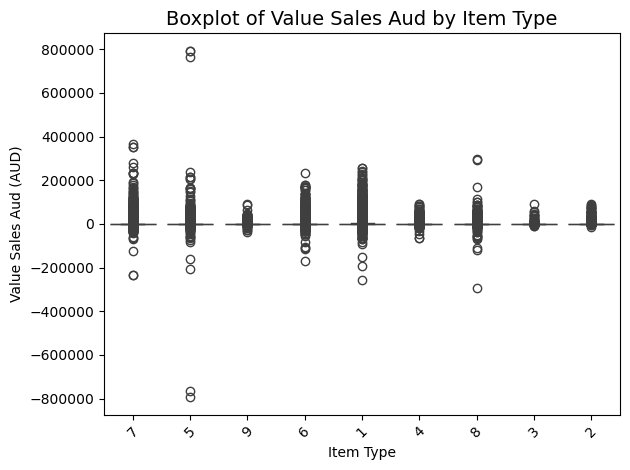

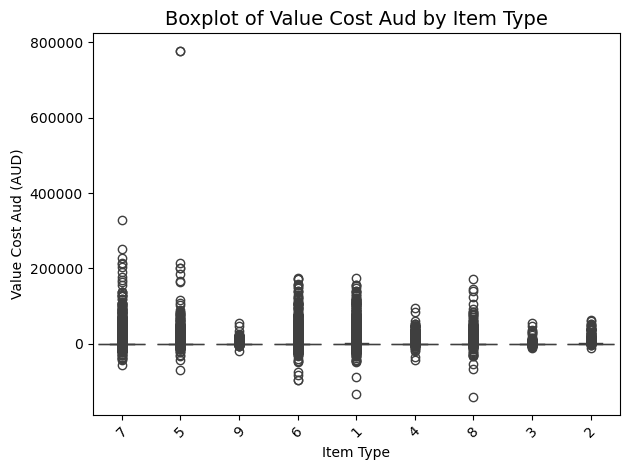

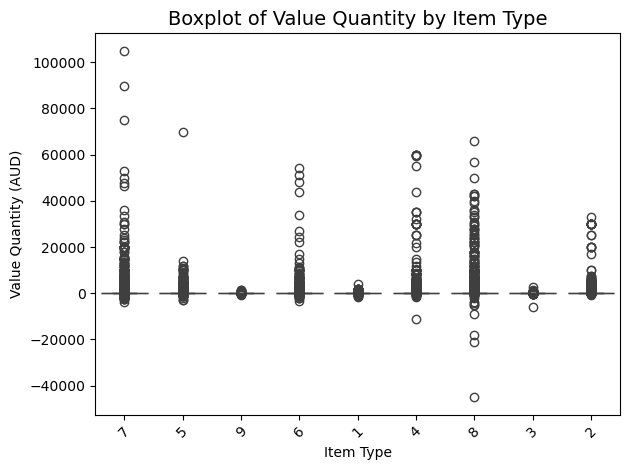

In [240]:
# Create boxplot for detecting outliers
columns_to_plot = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

for col in columns_to_plot:
    sns.boxplot(
        data=df_merge,
        x='item_type',
        y=col,
        showfliers=True,
        boxprops=dict(alpha=0.7)
    )
    plt.title(f'Boxplot of {col.replace("_", " ").title()} by Item Type', fontsize=14)
    plt.xlabel('Item Type')
    plt.ylabel(f'{col.replace("_", " ").title()} (AUD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Fix Outliers Round 1

In [241]:
def fix_outliers_signed_groupby(df, columns, group_col, verbose=True):
    df = df.copy()
    results = []

    for col in columns: 
        print(f"\n{'='*70}\n Fixing outliers for column: {col}\n{'='*70}")

        for group, subset in df.groupby(group_col):

            # Calculate Q1, Q3, IQR
            Q1 = subset[col].quantile(0.25)
            Q3 = subset[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            # Calculate median
            median_positive = subset.loc[subset[col] > 0, col].median()
            median_negative = subset.loc[subset[col] < 0, col].median()
        
            # Identify outliers
            mask_lower = (df[group_col] == group) & (df[col] < lower) 
            mask_upper = (df[group_col] == group) & (df[col] > upper)

            positive_outliers = mask_upper.sum()
            negative_outliers = mask_lower.sum()

            if verbose:
                print(f"\n Group: {group}")
                print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
                print(f"Median (+): {median_positive:.2f}, Median (-): {median_negative:.2f}")
                print(f"→ Positive outliers: {positive_outliers}")
                print(f"→ Negative outliers: {negative_outliers}")
                print(f"→ Total outliers: {positive_outliers + negative_outliers}")

            # Replace outliers within this group
            df.loc[mask_lower & (df[col] < 0), col] = median_negative
            df.loc[mask_upper & (df[col] > 0), col] = median_positive


            results.append({
                "column": col,
                "group": group,
                "lower": lower,
                "upper": upper,
                "median_positive": median_positive,
                "median_negative": median_negative,
                "positive_outliers": positive_outliers,
                "negative_outliers": negative_outliers
        })

    return df, pd.DataFrame(results)

columns_to_fix = ['value_sales_aud', 'value_cost_aud', 'value_quantity']
df_merge_round_1, summary_outliers = fix_outliers_signed_groupby(
    df_merge, 
    columns=columns_to_fix, 
    group_col='item_type', 
    verbose=True
)

print("\n✅ Done fixing all columns!")
display(summary_outliers)


 Fixing outliers for column: value_sales_aud

 Group: 1
Lower bound: -1961.91, Upper bound: 3678.39
Median (+): 524.00, Median (-): -194.77
→ Positive outliers: 21950
→ Negative outliers: 813
→ Total outliers: 22763

 Group: 2
Lower bound: -727.44, Upper bound: 1310.96
Median (+): 170.50, Median (-): -138.04
→ Positive outliers: 895
→ Negative outliers: 30
→ Total outliers: 925

 Group: 3
Lower bound: -205.35, Upper bound: 385.48
Median (+): 65.00, Median (-): -110.11
→ Positive outliers: 506
→ Negative outliers: 62
→ Total outliers: 568

 Group: 4
Lower bound: -277.16, Upper bound: 515.26
Median (+): 83.16, Median (-): -99.11
→ Positive outliers: 3011
→ Negative outliers: 273
→ Total outliers: 3284

 Group: 5
Lower bound: -193.71, Upper bound: 385.25
Median (+): 73.98, Median (-): -37.90
→ Positive outliers: 52458
→ Negative outliers: 4263
→ Total outliers: 56721

 Group: 6
Lower bound: -251.27, Upper bound: 495.88
Median (+): 86.05, Median (-): -76.11
→ Positive outliers: 31844
→ Ne

,column,group,lower,upper,median_positive,median_negative,positive_outliers,negative_outliers
0,value_sales_aud,1,-1961.912500,3678.387500,524.0000,-194.7700,21950,813
1,value_sales_aud,2,-727.440000,1310.960000,170.5000,-138.0400,895,30
2,value_sales_aud,3,-205.351250,385.478750,65.0000,-110.1110,506,62
3,value_sales_aud,4,-277.159000,515.265000,83.1600,-99.1100,3011,273
4,value_sales_aud,5,-193.713000,385.255000,73.9800,-37.9000,52458,4263
5,value_sales_aud,6,-251.270000,495.882000,86.0530,-76.1060,31844,3318
6,value_sales_aud,7,-145.597500,290.662500,53.1000,-33.2000,113036,9534
7,value_sales_aud,8,-383.700000,685.900000,100.4175,-107.0000,1074,244
8,value_sales_aud,9,-152.100000,408.700000,123.6000,-41.7000,4851,470
9,value_cost_aud,1,-1285.275000,2374.925000,312.6000,-107.5815,24082,563


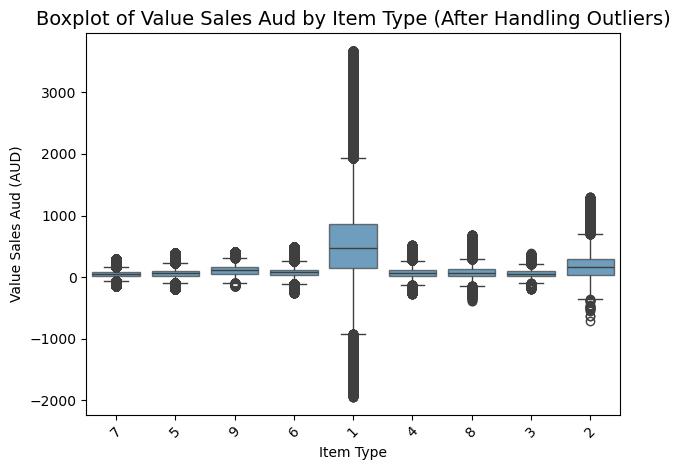

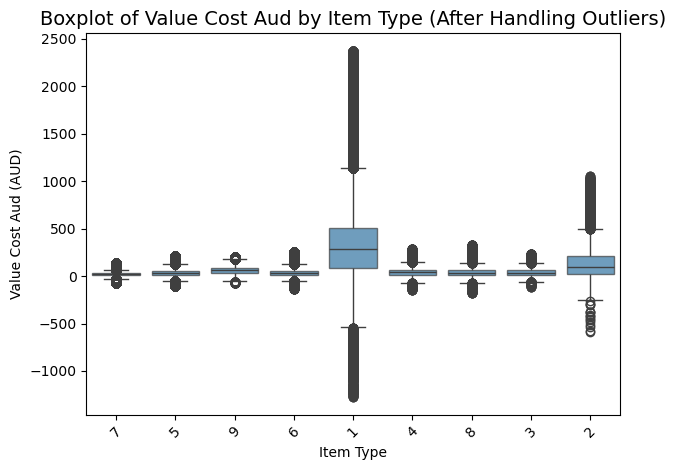

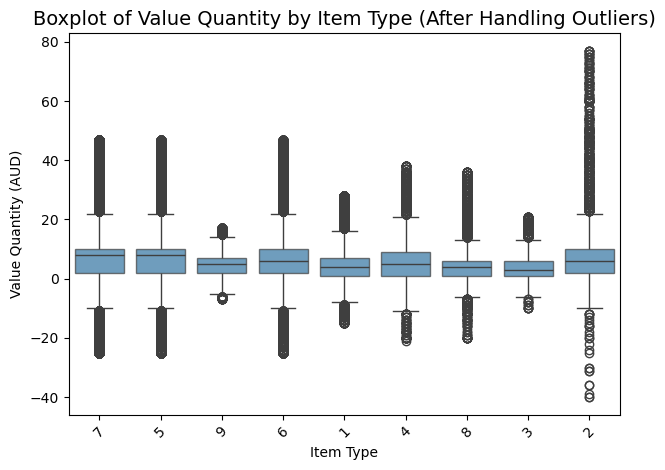

In [242]:
# Create boxplot after handling outliers
columns_to_plot = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

for col in columns_to_plot:
    sns.boxplot(
        data=df_merge_round_1,
        x='item_type',
        y=col,
        showfliers=True,
        boxprops=dict(alpha=0.7)
    )
    plt.title(f'Boxplot of {col.replace("_", " ").title()} by Item Type (After Handling Outliers)', fontsize=14)
    plt.xlabel('Item Type')
    plt.ylabel(f'{col.replace("_", " ").title()} (AUD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Check Skewness Round 1

In [243]:
cols = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

def classify_skew(x):
    if abs(x) <= 0.5:
        return '≈ Normal'
    elif abs(x) <= 1:
        return 'Mildly Skewed'
    else:
        return 'Highly Skewed'
    
skewness_summary_all = []

for group, subset in df_merge_round_1.groupby('item_type'):
    # Calculate skewness for each group
    skew_values = subset[cols].skew().round(3)
    skew_labels = skew_values.apply(classify_skew)

    results = pd.DataFrame({
        'item_type': group,
        'column': cols,
        'skew_value': skew_values.values,
        'skew_category': skew_labels.values
    })
    skewness_summary_all.append(results)
    
skewness_summary_df = pd.concat(skewness_summary_all, ignore_index=True)

pd.set_option('display.max_rows', None)
display(skewness_summary_df)

,item_type,column,skew_value,skew_category
0,1,value_sales_aud,1.611,Highly Skewed
1,1,value_cost_aud,1.777,Highly Skewed
2,1,value_quantity,1.603,Highly Skewed
3,2,value_sales_aud,1.627,Highly Skewed
4,2,value_cost_aud,1.763,Highly Skewed
5,2,value_quantity,2.382,Highly Skewed
6,3,value_sales_aud,1.191,Highly Skewed
7,3,value_cost_aud,1.269,Highly Skewed
8,3,value_quantity,1.481,Highly Skewed
9,4,value_sales_aud,1.445,Highly Skewed


### Fix Outliers Round 2

In [244]:
df_merge_round_2, summary_outliers = fix_outliers_signed_groupby(
    df_merge_round_1, 
    columns=columns_to_fix, 
    group_col='item_type', 
    verbose=True
)

print("\n✅ Done fixing all columns!")
display(summary_outliers)


 Fixing outliers for column: value_sales_aud

 Group: 1
Lower bound: -916.48, Upper bound: 1936.00
Median (+): 524.00, Median (-): -194.77
→ Positive outliers: 18494
→ Negative outliers: 682
→ Total outliers: 19176

 Group: 2
Lower bound: -357.60, Upper bound: 694.56
Median (+): 170.50, Median (-): -138.04
→ Positive outliers: 645
→ Negative outliers: 22
→ Total outliers: 667

 Group: 3
Lower bound: -98.48, Upper bound: 207.36
Median (+): 65.00, Median (-): -109.62
→ Positive outliers: 393
→ Negative outliers: 105
→ Total outliers: 498

 Group: 4
Lower bound: -130.18, Upper bound: 270.30
Median (+): 83.16, Median (-): -99.11
→ Positive outliers: 1819
→ Negative outliers: 156
→ Total outliers: 1975

 Group: 5
Lower bound: -96.30, Upper bound: 222.90
Median (+): 73.98, Median (-): -37.90
→ Positive outliers: 34542
→ Negative outliers: 3056
→ Total outliers: 37598

 Group: 6
Lower bound: -107.10, Upper bound: 255.61
Median (+): 86.05, Median (-): -76.11
→ Positive outliers: 22839
→ Negat

,column,group,lower,upper,median_positive,median_negative,positive_outliers,negative_outliers
0,value_sales_aud,1,-916.480000,1936.000000,524.00000,-194.77000,18494,682
1,value_sales_aud,2,-357.600000,694.560000,170.50000,-138.04000,645,22
2,value_sales_aud,3,-98.480000,207.360000,65.00000,-109.61650,393,105
3,value_sales_aud,4,-130.180000,270.300000,83.16000,-99.11000,1819,156
4,value_sales_aud,5,-96.300000,222.900000,73.98000,-37.90000,34542,3056
5,value_sales_aud,6,-107.105000,255.607000,86.05300,-76.10600,22839,2607
6,value_sales_aud,7,-69.300000,163.500000,53.10000,-33.20000,80673,8243
7,value_sales_aud,8,-145.500000,288.900000,100.41375,-107.00000,817,105
8,value_sales_aud,9,-97.500000,317.700000,123.60000,-41.70000,2268,224
9,value_cost_aud,1,-542.019750,1136.166250,312.60000,-107.56575,19496,526


### Check Skewness Round 2

In [245]:
cols = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

def classify_skew(x):
    if abs(x) <= 0.5:
        return '≈ Normal'
    elif abs(x) <= 1:
        return 'Mildly Skewed'
    else:
        return 'Highly Skewed'
    
skewness_summary_all = []

for group, subset in df_merge_round_2.groupby('item_type'):
    # Calculate skewness for each group
    skew_values = subset[cols].skew().round(3)
    skew_labels = skew_values.apply(classify_skew)

    results = pd.DataFrame({
        'item_type': group,
        'column': cols,
        'skew_value': skew_values.values,
        'skew_category': skew_labels.values
    })
    skewness_summary_all.append(results)
    
skewness_summary_df = pd.concat(skewness_summary_all, ignore_index=True)

pd.set_option('display.max_rows', None)
display(skewness_summary_df)

,item_type,column,skew_value,skew_category
0,1,value_sales_aud,1.090,Highly Skewed
1,1,value_cost_aud,1.133,Highly Skewed
2,1,value_quantity,1.177,Highly Skewed
3,2,value_sales_aud,1.172,Highly Skewed
4,2,value_cost_aud,1.470,Highly Skewed
5,2,value_quantity,1.067,Highly Skewed
6,3,value_sales_aud,0.184,≈ Normal
7,3,value_cost_aud,0.375,≈ Normal
8,3,value_quantity,0.884,Mildly Skewed
9,4,value_sales_aud,0.497,≈ Normal


### Fix Outliers Round 3

In [246]:
df_merge_round_3, summary_outliers = fix_outliers_signed_groupby(
    df_merge_round_2, 
    columns=columns_to_fix, 
    group_col='item_type', 
    verbose=True
)

print("\n✅ Done fixing all columns!")
display(summary_outliers)


 Fixing outliers for column: value_sales_aud

 Group: 1
Lower bound: -448.60, Upper bound: 1156.20
Median (+): 524.00, Median (-): -194.77
→ Positive outliers: 17276
→ Negative outliers: 945
→ Total outliers: 18221

 Group: 2
Lower bound: -193.06, Upper bound: 420.33
Median (+): 170.50, Median (-): -138.04
→ Positive outliers: 722
→ Negative outliers: 28
→ Total outliers: 750

 Group: 3
Lower bound: -56.98, Upper bound: 138.19
Median (+): 65.00, Median (-): -109.62
→ Positive outliers: 367
→ Negative outliers: 131
→ Total outliers: 498

 Group: 4
Lower bound: -74.74, Upper bound: 177.90
Median (+): 83.16, Median (-): -99.11
→ Positive outliers: 1464
→ Negative outliers: 563
→ Total outliers: 2027

 Group: 5
Lower bound: -65.10, Upper bound: 170.90
Median (+): 73.98, Median (-): -37.90
→ Positive outliers: 29944
→ Negative outliers: 2047
→ Total outliers: 31991

 Group: 6
Lower bound: -56.80, Upper bound: 171.76
Median (+): 86.05, Median (-): -76.11
→ Positive outliers: 20520
→ Negativ

,column,group,lower,upper,median_positive,median_negative,positive_outliers,negative_outliers
0,value_sales_aud,1,-448.600000,1156.200000,524.000000,-194.770000,17276,945
1,value_sales_aud,2,-193.065000,420.335000,170.500000,-138.040000,722,28
2,value_sales_aud,3,-56.975000,138.185000,65.000000,-109.616500,367,131
3,value_sales_aud,4,-74.740000,177.900000,83.160000,-99.110000,1464,563
4,value_sales_aud,5,-65.100000,170.900000,73.980000,-37.900000,29944,2047
5,value_sales_aud,6,-56.799500,171.764500,86.053000,-76.106000,20520,8226
6,value_sales_aud,7,-38.340000,111.900000,53.100000,-33.200000,69719,7831
7,value_sales_aud,8,-107.126250,224.943750,100.411875,-107.000000,294,51
8,value_sales_aud,9,-87.300000,300.700000,123.600000,-41.700000,904,57
9,value_cost_aud,1,-250.650000,650.550000,312.600000,-107.557875,18232,727


### Check Skewness Round 3

In [247]:
cols = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

def classify_skew(x):
    if abs(x) <= 0.5:
        return '≈ Normal'
    elif abs(x) <= 1:
        return 'Mildly Skewed'
    else:
        return 'Highly Skewed'
    
skewness_summary_all = []

for group, subset in df_merge_round_3.groupby('item_type'):
    # Calculate skewness for each group
    skew_values = subset[cols].skew().round(3)
    skew_labels = skew_values.apply(classify_skew)

    results = pd.DataFrame({
        'item_type': group,
        'column': cols,
        'skew_value': skew_values.values,
        'skew_category': skew_labels.values
    })
    skewness_summary_all.append(results)
    
skewness_summary_df = pd.concat(skewness_summary_all, ignore_index=True)

pd.set_option('display.max_rows', None)
display(skewness_summary_df)

,item_type,column,skew_value,skew_category
0,1,value_sales_aud,0.186,≈ Normal
1,1,value_cost_aud,0.100,≈ Normal
2,1,value_quantity,0.715,Mildly Skewed
3,2,value_sales_aud,0.260,≈ Normal
4,2,value_cost_aud,0.267,≈ Normal
5,2,value_quantity,0.001,≈ Normal
6,3,value_sales_aud,-1.122,Highly Skewed
7,3,value_cost_aud,-0.675,Mildly Skewed
8,3,value_quantity,0.776,Mildly Skewed
9,4,value_sales_aud,-0.532,Mildly Skewed


### Fix Outliers Round 4

In [248]:
df_merge_round_4, summary_outliers = fix_outliers_signed_groupby(
    df_merge_round_3, 
    columns=columns_to_fix, 
    group_col='item_type', 
    verbose=True
)

print("\n✅ Done fixing all columns!")
display(summary_outliers)


 Fixing outliers for column: value_sales_aud

 Group: 1
Lower bound: -403.00, Upper bound: 1080.20
Median (+): 524.00, Median (-): -194.77
→ Positive outliers: 2687
→ Negative outliers: 185
→ Total outliers: 2872

 Group: 2
Lower bound: -163.35, Upper bound: 370.81
Median (+): 170.50, Median (-): -138.04
→ Positive outliers: 167
→ Negative outliers: 11
→ Total outliers: 178

 Group: 3
Lower bound: -56.98, Upper bound: 138.19
Median (+): 65.00, Median (-): -109.62
→ Positive outliers: 0
→ Negative outliers: 131
→ Total outliers: 131

 Group: 4
Lower bound: -74.74, Upper bound: 177.90
Median (+): 83.16, Median (-): -99.11
→ Positive outliers: 0
→ Negative outliers: 563
→ Total outliers: 563

 Group: 5
Lower bound: -52.47, Upper bound: 149.85
Median (+): 73.98, Median (-): -37.90
→ Positive outliers: 13918
→ Negative outliers: 1165
→ Total outliers: 15083

 Group: 6
Lower bound: -56.80, Upper bound: 171.76
Median (+): 86.05, Median (-): -76.11
→ Positive outliers: 0
→ Negative outliers: 

,column,group,lower,upper,median_positive,median_negative,positive_outliers,negative_outliers
0,value_sales_aud,1,-403.00000,1080.20000,524.000000,-194.770000,2687,185
1,value_sales_aud,2,-163.35000,370.81000,170.500000,-138.040000,167,11
2,value_sales_aud,3,-56.97500,138.18500,65.000000,-109.616500,0,131
3,value_sales_aud,4,-74.74000,177.90000,83.160000,-99.110000,0,563
4,value_sales_aud,5,-52.47000,149.85000,73.980000,-37.900000,13918,1165
5,value_sales_aud,6,-56.79950,171.76450,86.053000,-76.106000,0,8226
6,value_sales_aud,7,-34.65000,105.75000,53.100000,-33.200000,11318,1649
7,value_sales_aud,8,-107.12625,224.94375,100.410937,-107.000000,0,0
8,value_sales_aud,9,-81.30000,290.70000,123.600000,-41.700000,511,49
9,value_cost_aud,1,-250.65000,650.55000,312.600000,-107.553937,0,0


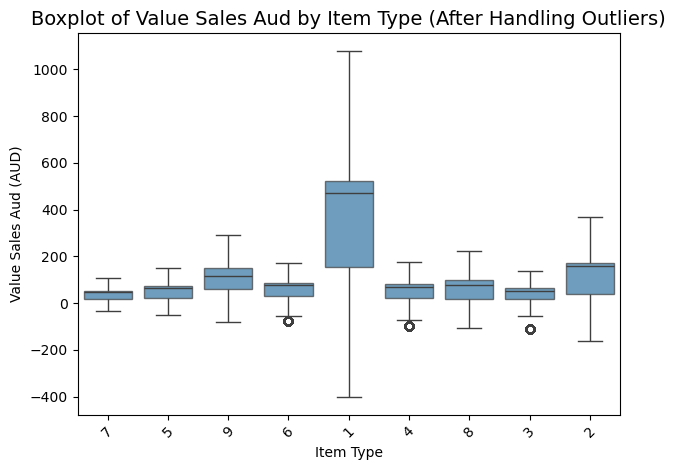

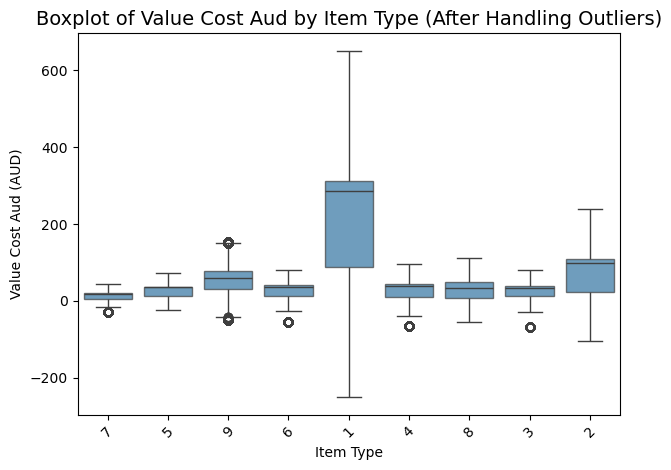

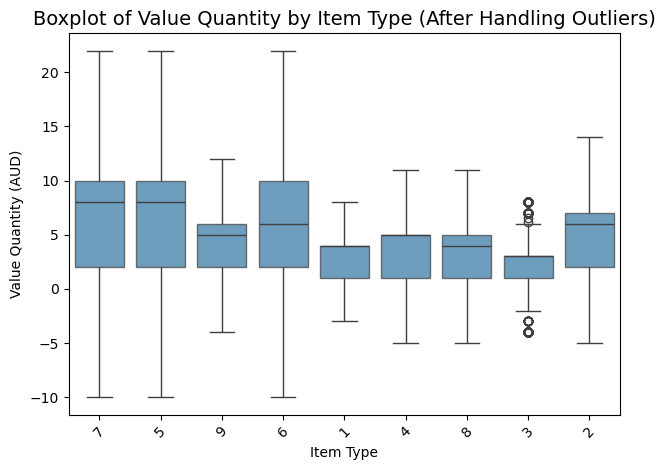

In [249]:
# Create boxplot after handling outliers
columns_to_plot = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

for col in columns_to_plot:
    sns.boxplot(
        data=df_merge_round_4,
        x='item_type',
        y=col,
        showfliers=True,
        boxprops=dict(alpha=0.7)
    )
    plt.title(f'Boxplot of {col.replace("_", " ").title()} by Item Type (After Handling Outliers)', fontsize=14)
    plt.xlabel('Item Type')
    plt.ylabel(f'{col.replace("_", " ").title()} (AUD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Check Skewness Round 4

In [250]:
cols = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

def classify_skew(x):
    if abs(x) <= 0.5:
        return '≈ Normal'
    elif abs(x) <= 1:
        return 'Mildly Skewed'
    else:
        return 'Highly Skewed'
    
skewness_summary_all = []

for group, subset in df_merge_round_4.groupby('item_type'):
    # Calculate skewness for each group
    skew_values = subset[cols].skew().round(3)
    skew_labels = skew_values.apply(classify_skew)

    results = pd.DataFrame({
        'item_type': group,
        'column': cols,
        'skew_value': skew_values.values,
        'skew_category': skew_labels.values
    })
    skewness_summary_all.append(results)
    
skewness_summary_df = pd.concat(skewness_summary_all, ignore_index=True)

pd.set_option('display.max_rows', None)
display(skewness_summary_df)

,item_type,column,skew_value,skew_category
0,1,value_sales_aud,0.034,≈ Normal
1,1,value_cost_aud,0.100,≈ Normal
2,1,value_quantity,0.021,≈ Normal
3,2,value_sales_aud,-0.003,≈ Normal
4,2,value_cost_aud,0.159,≈ Normal
5,2,value_quantity,0.001,≈ Normal
6,3,value_sales_aud,-1.122,Highly Skewed
7,3,value_cost_aud,-1.238,Highly Skewed
8,3,value_quantity,-0.053,≈ Normal
9,4,value_sales_aud,-0.532,Mildly Skewed


## Feature Engineering (New Variables)

### Total Revenue

* Column `value_price_adjustment` contain only binary values: 

    * **0:** no price adjustment (e.g., discount or surcharge) was apply
    
    * **1:**  discount or surcharge

So cannot calculate total revenue using `total_revenue = value_sales_aud + value_price_adjustment`

* Use `value_sales_aud` as `total_revenue` directly (because it already reflects the final amount after any adjustments)

In [251]:
df_merge_round_4['total_revenue'] = df_merge_round_4['value_sales_aud']
df_merge_round_4[['value_sales_aud', 'total_revenue']].head()

,value_sales_aud,total_revenue
322974,55.90,55.90
354229,31.55,31.55
271073,42.75,42.75
361028,101.70,101.70
319254,15.28,15.28


### Profit

`profit = value_sales_aud - value_cost_aud`

In [252]:
df_merge_round_4['profit'] = df_merge_round_4['value_sales_aud'] - df_merge_round_4['value_cost_aud']

df_merge_round_4[['value_sales_aud', 'value_cost_aud', 'profit']].head()

,value_sales_aud,value_cost_aud,profit
322974,55.90,24.939,30.961
354229,31.55,18.626,12.924
271073,42.75,21.458,21.292
361028,101.70,21.476,80.224
319254,15.28,5.758,9.522


### Profit Margin

`profit_margin = (value_sales_aud - value_cost_aud) / value_sales_aud`

**Reason for assign `NaN` only when `value_sales` == 0**:

* **1. To avoide divide by zero:** Since `profit_margin` is calculated as:
    `profit_margin = (value_sales_aud - value_cost_aud) / value_sales_aud`

-> dividing by zero would raise an error or produce meaningless values. So, when `value_sales_aud == 0`, it’s safer and more appropriate to assign `NaN`.

* **2. No business meaning when sales = 0:** If there’s no revenue (`value_sales_aud = 0`), calculating a margin doesn’t make sense. There’s no sale, so the margin is undefined.

* **3. Cost = 0 still has meaning:** 
    * If `value_cost_aud == 0` but there is a sale, this might represent valid business scenarios, such as:
        * Free goods from suppliers (e.g., marketing promotions) 
        * Fully depreciated stock.
        * Accounting lags (cost not recorded yet).
    * These transactions result in a 100% profit margin, which is not incorrect from a calculation perspective.
* **4. Don’t want to throw away useful data:** If you also assign NaN when `value_cost_aud == 0`, you’ll remove potentially valuable rows that could highlight interesting patterns like very high-margin sales, zero-cost samples, or promotion campaigns.

* **5. More flexible for later analysis:** If needed, you can always flag or filter out `value_cost_aud == 0` later when analyzing outliers or building models—but keeping the data for now retains maximum flexibility.

In [253]:
df_merge_round_4['profit_margin'] = np.where(
    df_merge_round_4['value_sales_aud'] == 0,
    np.nan,
    (df_merge_round_4['value_sales_aud'] - df_merge_round_4['value_cost_aud']) / df_merge_round_4['value_sales_aud']
)

df_merge_round_4[['value_sales_aud', 'value_cost_aud', 'profit_margin']].head()

,value_sales_aud,value_cost_aud,profit_margin
322974,55.90,24.939,0.553864
354229,31.55,18.626,0.409635
271073,42.75,21.458,0.498058
361028,101.70,21.476,0.788830
319254,15.28,5.758,0.623168


### Order Month

`order_month = month from order_date` -> seasonality research

In [254]:
df_merge_round_4['order_month'] = df_merge_round_4['order_date'].dt.month

df_merge_round_4[['order_date', 'order_month']].head()

,order_date,order_month
322974,2022-12-22,12
354229,2022-12-20,12
271073,2022-12-20,12
361028,2022-12-19,12
319254,2022-12-22,12


### Days to Invoice

`days_to_invoice = invoice_date – order_date`

In [255]:
df_merge_round_4['days_to_invoice'] = (df_merge_round_4['invoice_date'] - df_merge_round_4['order_date']).dt.days

df_merge_round_4[['invoice_date', 'order_date', 'days_to_invoice']].head()

,invoice_date,order_date,days_to_invoice
322974,2023-01-02,2022-12-22,11
354229,2023-01-02,2022-12-20,13
271073,2023-01-02,2022-12-20,13
361028,2023-01-02,2022-12-19,14
319254,2023-01-02,2022-12-22,11


# Section 2: Exploratory Insights

## section 2.1 - Total Revenue by Year (all the codes in one cell - do not insert extra cells) 

<Figure size 1200x600 with 0 Axes>

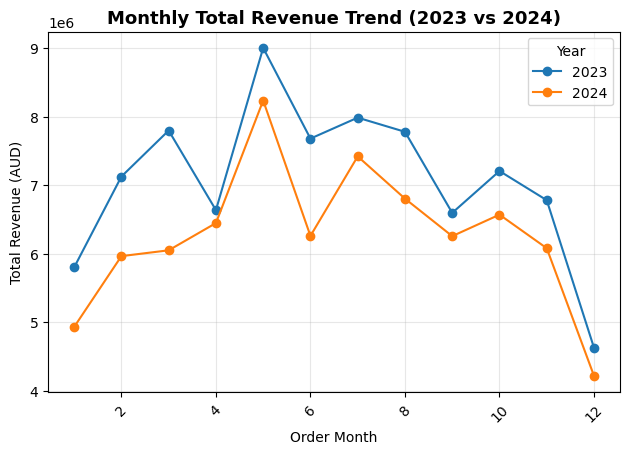

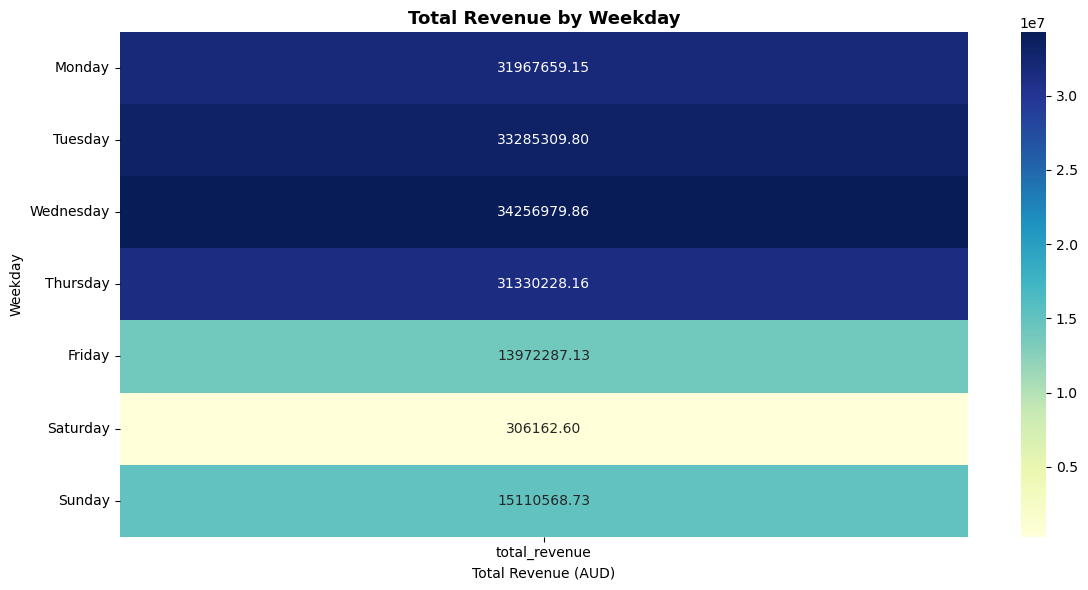

In [256]:
df_visualisation = df_merge_round_4.copy()

# Extract year and month for monthly revenue analysis
df_visualisation['year'] = df_visualisation['accounting_date'].dt.year

# Monthly Total Revenue Trend Line Chart for 2023 and 2024
monthly_revenue = df_visualisation[df_visualisation['year'].isin([2023, 2024])].groupby(['order_month', 'year'])['total_revenue'].sum().unstack()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(marker='o')
plt.title('Monthly Total Revenue Trend (2023 vs 2024)', fontsize=13, weight='bold')
plt.xlabel('Order Month')
plt.ylabel('Total Revenue (AUD)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### **Findings** 

1. **Seasonal Revenue Trend (2023 vs 2024)**

   * Revenue in both 2023 and 2024 shows **strong monthly seasonality**.
     Peaks occur in **May (≈ Q2)** and **July–August (mid-year shopping periods)**, while noticeable declines appear towards **December**, suggesting reduced purchasing at the end of the fiscal cycle.
   * **2024 revenue trails 2023** across almost all months, indicating either reduced order volume or pricing adjustments.
     The most significant gap occurs in **May and June**, hinting that mid-year campaigns were **less effective** in 2024.
   * Post-August, both years demonstrate parallel movement, implying that **seasonal demand drivers (e.g., climate or recurring promotions)** remained stable year to year.

2. **Revenue Concentration by Weekday**

   * The heatmap reveals that **Monday → Thursday** generate the **highest sales**, with **Wednesday** being the single top-performing day.
   * Revenue **drops sharply on weekends**, especially **Saturday**, suggesting either store closures or lower online traffic.
   * The smooth weekday pattern reflects **a business model dominated by B2B or contract-based orders**, where purchasing typically occurs on working days rather than consumer weekends.

### **Managerial Implications**

1. **Marketing & Sales Planning**

   * Reinforce marketing and discount campaigns around **May–July**, the months showing historical peaks.
   * Investigate the 2024 mid-year dip → optimize campaign timing or evaluate product availability during that window.

2. **Operational Efficiency**

   * Since weekday sales dominate, align staffing, logistics, and inventory replenishment schedules with **Monday–Thursday** demand peaks.
   * Streamline weekend operations—focus on online automation or cost-saving measures rather than full staffing.

3. **Strategic Forecasting**

   * Incorporate both **monthly seasonality** and **weekday sales cycles** into revenue-forecasting models to improve precision.
   * If the goal is growth in 2025, prioritize increasing Friday and weekend conversion through online channels or extended service hours.


## section 2.2 - Profit by Item & District Code 

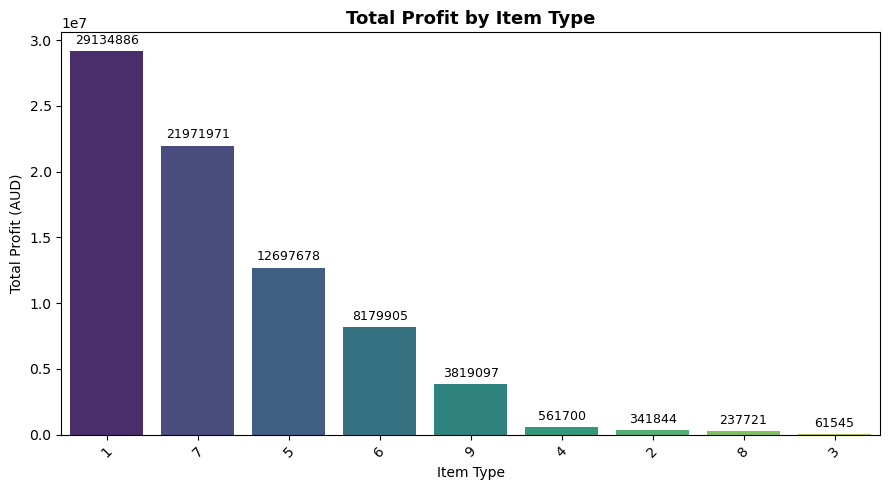

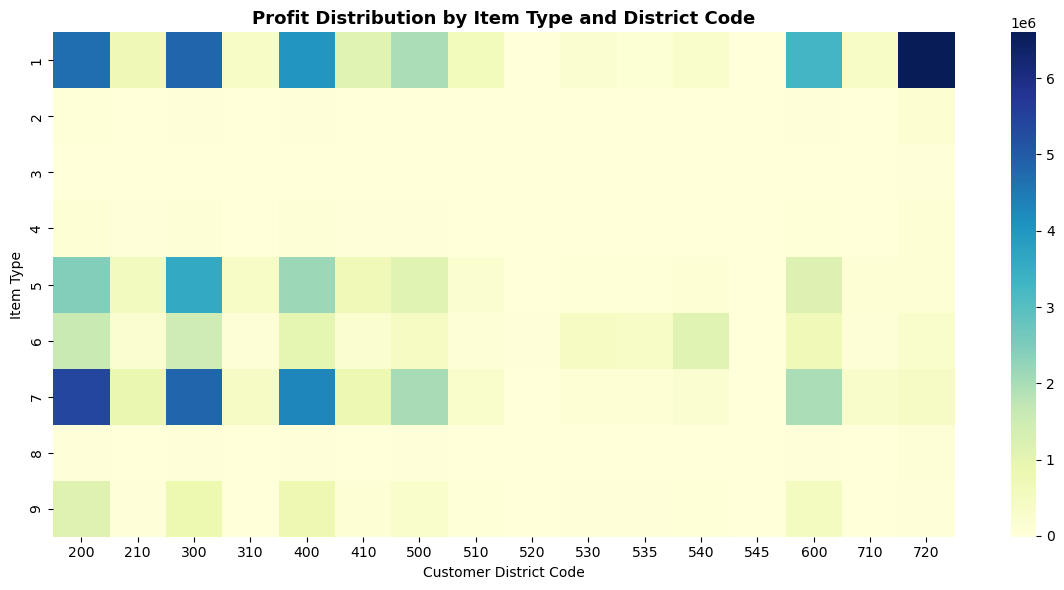

In [257]:
df_visualisation = df_merge_round_4.copy()

# Calculate total profit by item type
profit_by_type = (
    df_visualisation.groupby('item_type')['profit']
    .sum()
    .reset_index()
    .sort_values(by='profit', ascending=False)
)

# 1. Profit by Item Type
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=profit_by_type,
    x='item_type', 
    y='profit', 
    hue='item_type', 
    palette='viridis', 
    legend=False
)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9, color='black')

plt.title('Total Profit by Item Type', fontsize=13, weight='bold')
plt.xlabel('Item Type')
plt.ylabel('Total Profit (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Profit by Item Type and District (Heatmap)
profit_heatmap = (
    df_visualisation.groupby(['item_type', 'customer_district_code'])['profit']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
sns.heatmap(profit_heatmap, cmap='YlGnBu')
plt.title('Profit Distribution by Item Type and District Code', fontsize=13, weight='bold')
plt.xlabel('Customer District Code')
plt.ylabel('Item Type')
plt.tight_layout()
plt.show()


### **Findings**

1. **Profit Concentration:**

   * The bar chart reveals that **a small number of product types (Item Type 1, 7, and 5)** contribute the majority of the company’s total profit.
   * *Item Type 1* generates the highest profit (~29 million AUD), more than twice that of *Item Type 7*, the next most profitable group.
   * Lower-ranked product types (*e.g.*, Type 2, 3, 8, 4) contribute minimally to total profit, indicating an imbalanced portfolio.

2. **Geographical Profit Distribution:**

   * The heatmap demonstrates that **profitability is highly concentrated in a few key customer districts** — particularly *District Codes 200, 300, 600, and 720*.
   * *Item Type 1* and *7* dominate these regions, while several areas (*e.g.*, 500–540) show weak or near-zero profit contribution.
   * This suggests that **certain regional markets are significantly outperforming others**, likely due to customer density, pricing strategies, or logistics efficiency.

### **Managerial Implications**

1. **Strategic Focus on High-Profit Segments**

   * Management should prioritize **investment, marketing, and sales resources** toward *Item Types 1, 7, and 5*, which drive the company’s profitability.
   * These product lines represent **core revenue engines** that can sustain growth if supported with targeted marketing and inventory management.

2. **Regional Performance Optimization**

   * The firm should **analyze the high-performing districts (200, 300, 600, 720)** to identify key success factors such as local demand patterns, customer loyalty, or efficient distribution channels.
   * Conversely, **low-profit regions** may require operational restructuring, pricing adjustments, or even withdrawal if cost-to-serve is too high.

3. **Portfolio Rationalization**

   * The low-performing product types (*2, 3, 8, 9*) should be **evaluated for discontinuation or repositioning**, as maintaining them might dilute overall profitability.
   * Streamlining the product portfolio could enhance **operational efficiency and improve average profit margins**.

4. **Next Analytical Step**

   * Further analysis on **profit margin and cost structure by item type** can help determine whether profitability stems from sales volume or higher margins.
   * Combining this with **customer segmentation data** will support more data-driven decisions on regional product mix and pricing strategy.


## section 2.3 - Return Rate by Item Type (all the codes in one cell - do not insert extra cells) 

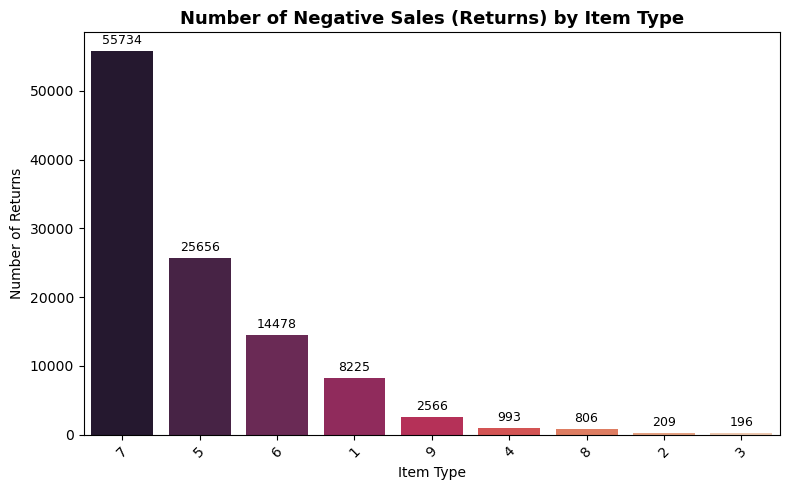

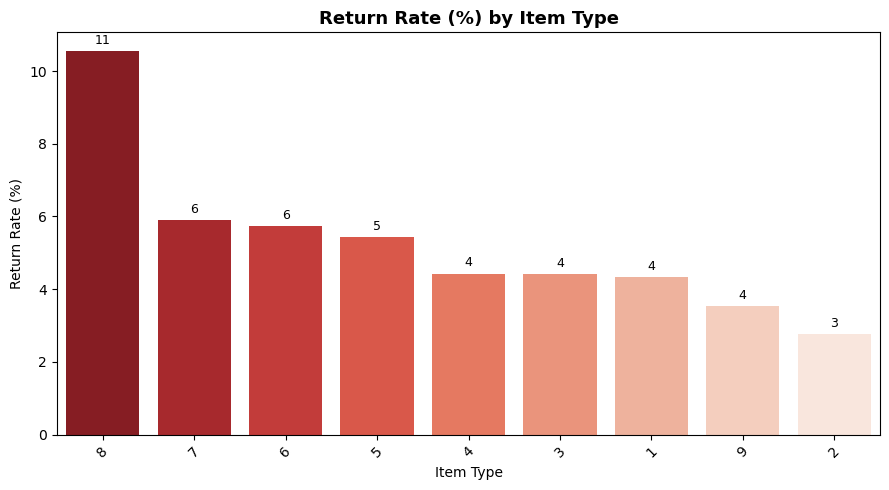

In [258]:
df_visualisation = df_merge_round_4.copy()

# Identify return transactions (negative sales)
df_visualisation['is_return'] = df_visualisation['value_sales_aud'] < 0

# Count the number of return transactions per item type
returns_by_type = (
    df_visualisation[df_visualisation['is_return']]
    .groupby('item_type')['value_sales_aud']
    .count()
    .reset_index()
    .sort_values('value_sales_aud', ascending=False)
)

# 1. Number of Returns by Item Type
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=returns_by_type, 
    x='item_type', 
    y='value_sales_aud', 
    hue='item_type',
    palette='rocket',
    legend=False
)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9, color='black')

plt.title('Number of Negative Sales (Returns) by Item Type', fontsize=13, weight='bold')
plt.xlabel('Item Type')
plt.ylabel('Number of Returns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Returns by Item Type
# Calculate return rate (%) by item type
return_rate_type = (
    df_visualisation.groupby('item_type')['is_return']
    .mean()
    .reset_index()
)
return_rate_type['return_rate_%'] = (return_rate_type['is_return'] * 100).round(2)
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=return_rate_type.sort_values('return_rate_%', ascending=False),
    x='item_type',
    y='return_rate_%',
    hue='item_type',
    palette='Reds_r',
    legend=False
)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9, color='black')

plt.title('Return Rate (%) by Item Type', fontsize=13, weight='bold')
plt.xlabel('Item Type')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Findings**

1. **Return Volume Distribution**

   * The first chart shows that **Item Type 7** recorded the highest number of return transactions (≈55,700), followed by *Type 5* and *Type 6*.
   * These top three product types collectively account for **over 80% of all returns**, suggesting they dominate both sales and after-sales issues.
   * Conversely, *Types 2, 3, and 8* have minimal return counts, indicating smaller sales volumes or better product quality/stability.

2. **Return Rate Variation**

   * The second chart highlights that **Item Type 8 has the highest return rate (~11%)**, despite having fewer total returns.
   * *Types 7 and 6* also exhibit relatively high return rates (around 6%), while *Type 2* shows the lowest (≈3%).
   * This reveals that **return rate does not always correlate with sales volume** — some niche products (like Type 8) may have persistent quality or compatibility issues.

### **Managerial Implications**

1. **Targeted Quality Control**

   * *Item Types 8, 7, and 6* require immediate investigation into **manufacturing quality, packaging, or post-sale support** to reduce return frequency.
   * Implementing product testing or stricter supplier standards could significantly cut return costs.

2. **Operational Cost Impact**

   * High-volume items with large numbers of returns (*Types 7, 5, 6*) may be inflating **reverse logistics and handling expenses**.
   * Management should explore **root-cause analysis of return reasons** and strengthen the **customer return verification process**.

3. **Customer Experience & Brand Perception**

   * A high return rate can damage customer trust and brand reputation.
   * Introducing **return pattern monitoring dashboards** can help the company identify spikes early and take proactive corrective actions.

4. **Strategic Decision-Making**

   * The company should **balance return rate and sales volume** when evaluating product profitability.
   * Product types with high revenue but also high return ratios may still yield low net profit once processing and logistics costs are included.

## section 2.4 - Revenue & Profit by Currency (all the codes in one cell - do not insert extra cells) 

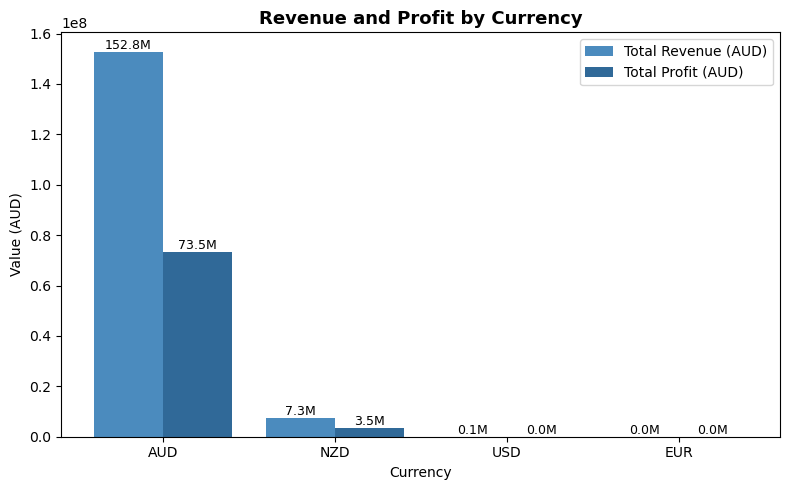

In [259]:
# Create a copy for visualization
df_visualisation = df_merge_round_4.copy()

# Aggregate total revenue and profit by currency
currency_summary = (
    df_visualisation.groupby('currency')[['value_sales_aud', 'profit']]
    .sum()
    .reset_index()
    .sort_values(by='value_sales_aud', ascending=False)
)

plt.figure(figsize=(8,5))
bar_width = 0.4
x = range(len(currency_summary))

# Plot total revenue
bars1 = plt.bar(x, currency_summary['value_sales_aud'], 
                width=bar_width, label='Total Revenue (AUD)', color='#4B8BBE')

# Plot total profit
bars2 = plt.bar([i + bar_width for i in x], currency_summary['profit'], 
                width=bar_width, label='Total Profit (AUD)', color='#306998')

# Add value labels on top of bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height()/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height()/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
    
plt.xticks([i + bar_width/2 for i in x], currency_summary['currency'])
plt.title('Revenue and Profit by Currency', fontsize=13, weight='bold')
plt.xlabel('Currency')
plt.ylabel('Value (AUD)')
plt.legend()
plt.tight_layout()
plt.show()


### **Findings**

1. **AUD Dominates Performance**
   * The Australian Dollar (AUD) accounts for the **overwhelming majority of total revenue (≈ 153 M AUD)** and profit (≈ 73 M AUD), far exceeding all other currencies combined.
   * This indicates that the company’s operations are **heavily concentrated in the Australian market**, with domestic transactions driving profitability.

2. **Secondary Markets**
   * The **New Zealand Dollar (NZD)** contributes modestly (≈ 7 M AUD in revenue and 3.5 M AUD in profit), showing some cross-border trade presence.
   * However, **USD and EUR** transactions are almost negligible, suggesting limited international exposure or inactive overseas sales channels.

3. **Profitability Alignment**
   * The proportional relationship between revenue and profit in AUD and NZD implies **consistent margin structures** across these currencies, without major pricing or cost discrepancies.

### **Managerial Implications**

1. **Strategic Focus on Core Market**
   * The strong performance in AUD confirms **domestic market leadership**. Management should continue optimizing local pricing, logistics, and customer engagement, as this region represents the backbone of profitability.

2. **Diversification Opportunity**
   * The extremely low contribution from USD and EUR indicates **untapped global potential**. Expanding export strategies or strengthening partnerships in these regions could **reduce dependency on one currency** and hedge against local economic fluctuations.

3. **Currency Risk Management**
   * Since earnings are almost entirely in AUD, the company faces **concentration risk** if the AUD weakens. Implementing **currency hedging policies** or **increasing multi-currency invoicing** can mitigate exchange-rate volatility.

4. **Operational Insight**
   * Maintaining similar profit ratios across AUD and NZD regions suggests stable pricing and cost control mechanisms. This can serve as a **benchmark model** when scaling operations into new currency markets.

## section 2.5 - Top 10 Customers by Total Revenue (AUD) (all the codes in one cell - do not insert extra cells) 

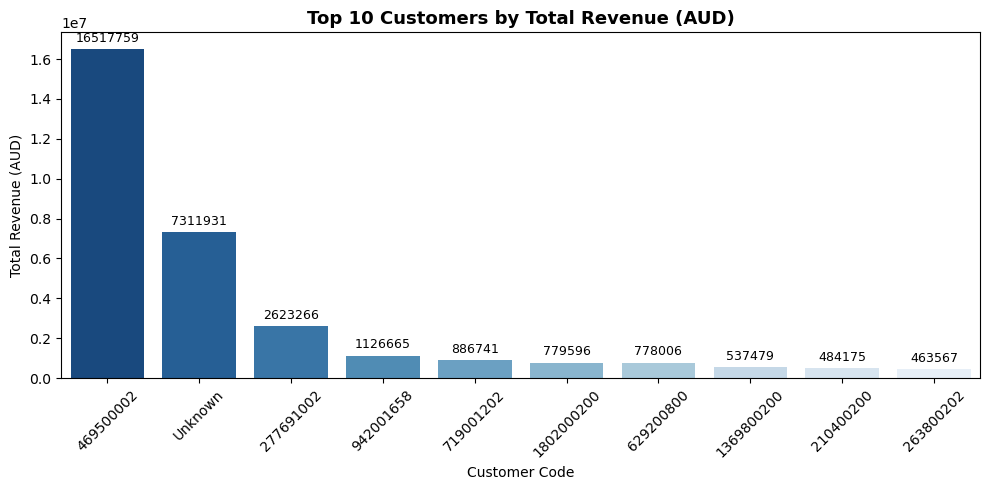

In [260]:
# Create a copy for visualization
df_visualisation = df_merge_round_4.copy()

# Calculate total revenue per customer
top_customers = (
    df_visualisation.groupby('customer_code')['value_sales_aud']
    .sum()
    .reset_index()
    .sort_values('value_sales_aud', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_customers,
    x='customer_code',
    y='value_sales_aud',
    hue='customer_code',
    palette='Blues_r',
    legend=False
)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9, color='black')

plt.title('Top 10 Customers by Total Revenue (AUD)', fontsize=13, weight='bold')
plt.xlabel('Customer Code')
plt.ylabel('Total Revenue (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Findings**

1. **Highly Concentrated Customer Base**
   * Revenue is heavily dominated by a few key accounts — the **top customer (code 469500002)** alone generates approximately **16.5 million AUD**, followed by a second major customer (“Unknown”) with **7.3 million AUD**.
   This means the top two customers together account for **more than 70% of total revenue** within the top 10, revealing a strong dependency on a limited number of clients.

2. **Long Tail of Small Accounts**
   * Beyond the top three customers, revenue contribution drops sharply. Customers ranked from 4th to 10th each contribute **below 1.2 million AUD**, indicating a **steep revenue gap** between strategic accounts and general clients.

3. **Potential Data Gaps**
   * The presence of an “Unknown” customer suggests **incomplete or inconsistent customer data**, which may distort revenue tracking or limit personalized engagement strategies.

### **Managerial Implications**

1. **Strengthen Key Account Management**
   * The top two customers are **critical to business stability**. Management should assign **dedicated account managers**, strengthen service quality, and implement **retention strategies** (e.g., volume discounts, exclusive service tiers) to prevent revenue loss from these key accounts.

2. **Diversify Customer Portfolio**
   * Heavy reliance on a small number of customers poses **revenue concentration risk**. Management should focus on **expanding mid-tier clients**, increasing the number of medium-value accounts to create a more balanced revenue structure.

3. **Improve Data Quality**
   * The “Unknown” category highlights a **data governance issue**. Implementing standardized customer identifiers and enforcing data validation during transaction entry can **improve accuracy** in revenue and profitability analysis.

4. **Strategic Growth Opportunities**
   * The lower-tier customers represent **potential for upselling and cross-selling**. Tailored campaigns targeting these clients with bundled offers or service upgrades could improve their contribution to total revenue.

# Section 3: Test Sub Sample Differences 

## section 3.1 - Q1: Did the average profit margin significantly decrease from 2023 to 2024? (all the codes in one cell - do not insert extra cells) 

#### **Two Sample Test**
* **Null Hypothesis (H0)**: There is no decrease in profit margin from 2023 to 2024.  <br>
$$μ_{2023} \le μ_{2024}$$
* **Alternative Hypothesis (Ha)**: There is a decrease in profit margin from 2023 to 2024. <br>
$$μ_{2023}  >  μ_{2024}$$

In [261]:
# Copy the base dataset
df_section3 = df_merge_round_4.copy()
df_section3['year'] = df_section3['accounting_date'].dt.year

# Make sure the relevant columns are available
profit_2023 = df_section3[df_section3['year'] == 2023]['profit_margin'].dropna()
profit_2024 = df_section3[df_section3['year'] == 2024]['profit_margin'].dropna()

# Perform a two-sample t-test
t_stat, p_value = ttest_ind(profit_2023, profit_2024, alternative='greater')
alpha = 0.05

# Print results
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

print(f"Mean Profit Margin 2023: {profit_2023.mean():.4f}")   
print(f"Mean Profit Margin 2024: {profit_2024.mean():.4f}")

if p_value < alpha:
    print("Reject the null hypothesis: There is a decrease in profit margins from 2023 to 2024.")
else:
    print("Fail to reject the null hypothesis: No decrease in profit margins from 2023 to 2024.")

T-statistic: -2.5527
P-value: 0.9947
Mean Profit Margin 2023: 0.4313
Mean Profit Margin 2024: 0.4970
Fail to reject the null hypothesis: No decrease in profit margins from 2023 to 2024.


#### **Business Interpretation - Year-over-Year Profit Margin (2023 vs 2024)**
* No significant evidence of a decrease in profit margins was found between **2023** and **2024** (*p*= 0.9947 > 0.05, one-tailed).
* The **average profit margin actually increased** from **0.4313** in 2023 to **0.4970** in 2024.
* This indicates that **profitability improved rather than declined** during the period.
* This could suggest:
  * **Better cost management** or improved operational efficiency in 2024,
  * **Enhanced pricing discipline** or fewer margin-ending discounts, or
  * A **shift in product or customer mix** toward higher-margin segments.

Conversely, if a decline had been expected , the data suggest the opposite trend - **margin strengthening**, potentially reflecting the positive impact of 2024 strategic or process initiatives.

## section 3.2 - Q2: Does invoicing speed (≤10 days vs >30 days) significantly affect profit margin? 

#### **Two Sample Test**
* **Null Hypothesis (H0)**: There is no significant difference in mean profit margin between slow and fast invoicing groups.  <br>
$$μ_{s} = μ_{f}$$
* **Alternative Hypothesis (Ha)**: There is a significant difference in mean profit margin between slow invoicing groups.<br>
$$μ_{s}  \ne  μ_{f}$$

In [262]:
# Copy the base dataset
df_time = df_merge_round_4.copy()

# Make sure the relevant columns are available
df_time = df_time.dropna(subset=['days_to_invoice', 'profit_margin'])

# Define two groups:
# Group 1: Fast invoicing (<= 10 days)
# Group 2: Slow invoicing (> 30 days)
fast = df_time[df_time['days_to_invoice'] <= 10]['profit_margin']
slow = df_time[df_time['days_to_invoice'] > 30]['profit_margin']

# Perform two-sample t-test 
t_stat, p_value = ttest_ind(fast, slow, equal_var=False)

# Print results
print(f'T-statistic:{t_stat:.4f}')
print(f'P-value:{p_value:.4f}')
print(f'Mean Profit Margin (Fast):{fast.mean():.4f}')
print(f'Mean Profit Margin (Slow):{slow.mean():.4f}')

alpha = 0.05
if p_value < alpha:
    print('Reject the null hypothesis: There is a significnat difference in profit margins beween fast and slow invoicing groups.')
else:
    print('Fail to reject the null hypothesis: No significant difference in profit margins between fast and slow invoicing group.')

T-statistic:0.5303
P-value:0.5959
Mean Profit Margin (Fast):0.4637
Mean Profit Margin (Slow):0.4475
Fail to reject the null hypothesis: No significant difference in profit margins between fast and slow invoicing group.


#### **Business Interpretation - Invoicing Speed vs. Profit Margin**
* **No significant difference in profit margins** was observed between **fast** (≤ 10 days) and **slow** (> 30 days) invoicing groups (*p*=0.596 > 0.05).
* This indicates that **invoice processing speed does not materially influence profitability** within the analyzed dataset.
* This could suggest:
  * **Similar pricing or cost structures** regardless of invoicing efficiency, or
  * **Limited operational impact** of invoicing speed on realized margins, or
  * **Other dominant factors** (e.g., product mix, customer terms) overshadowing invoicing timing effects.

Conversely, while faster invoicing shows a slightly higher average margin, this difference is **statistically insignificant** and likely due to random variation rather than a systematic advantage.

## section 3.3 - Q3: Did the average price adjustment amount per invoice change significantly between 2023 and 2024? 

#### **Two Sample Test**
* **Null Hypothesis (H0)**: mean adjustment amount for 2023 and 2024 are euqal. <br>
$$μ_{2023} = μ_{2024}$$
* **Alternative Hypothesis (Ha)**: mean adjustment amount for 2023 and 2024 are not euqal.<br>
$$μ_{2023}  \ne  μ_{2024}$$

In [263]:
# Copy the base dataset
df_year = df_merge_round_4.copy()

df_year['year'] = df_year['accounting_date'].dt.year

# Keep only adjustment lines (negative value_sales)
df_year ['adj_amount'] = df_year.loc[df_year['value_price_adjustment'] == '1.0','value_sales_aud']

# Drop na value in adj amount column
df_year = df_year.dropna(subset=['adj_amount'])

# Aggregate total adjustment amount per invoice per year 
inv_adj = (df_year.groupby(['year','invoice_number'], as_index = False)['adj_amount'].sum())

# Create two samples for t-test
adj_2023 = inv_adj.loc[inv_adj['year'] == 2023, 'adj_amount']
adj_2024 = inv_adj.loc[inv_adj['year'] == 2024, 'adj_amount']

# Two-sample t test (mean comparison)
t_stat, p_value = ttest_ind(adj_2023, adj_2024, equal_var=False, nan_policy='omit')

print(f"T-statistic: {t_stat:.4f}")
print(f"Two-tailed p-value: {p_value:.4f}")
print(f"Mean 2023: {adj_2023.mean():.2f}")
print(f"Mean 2024: {adj_2024.mean():.2f}")

alpha = 0.05
if p_value < alpha:
    print('Reject the null hypothesis: There is a significant difference in mean adjustment amounts between 2023 and 2024.')
else:
    print('Fail to reject the null hypothesis: No significant difference in Mean adjustment amount between 2023 and 2024.')

T-statistic: 3.2312
Two-tailed p-value: 0.0012
Mean 2023: -39.25
Mean 2024: -45.15
Reject the null hypothesis: There is a significant difference in mean adjustment amounts between 2023 and 2024.


### **Business Interpretation - Price Adjustment (2023 vs 2024)**
*  **2024 adjustments are more negative** (*p* = 0.0012 < 0.05), indicating **larger discounts**, **rebates**, **or posy-invoice corrections** compared with 2023.
*  This shows that overall **adjustment activity intensified** in 2024.
* This could indicate:
  * **More frequent price corrections or credit notes** being issued, or
  * **Tighter pricing environment**  with greater post-sales adjustments, or
  * **Operational inefficiencies** in invoicing or pricing controls compared to 2023.

Conversely, if these adjustments represent **rebates or credits**, it may reflect:
* **Stronger customer pressure** on pricing
* **Policy changes** introduced in 2024 affecting discount or rebate structures.

# Section 4: Inference - Question: How do seasonable factors (such as fiscal_year and fiscal_month), customer demographics (e.g., district and business chain codes), product characteristics (including item type, item group, item class, and ABC volume classification), and order attributes (order type and value adjustments) impact the sales value in AUD? 

In [264]:
# Encode abc_class_code categorical variable into numerical values
abc_code_encoder = {'A': 10, 'B': 9, 'C': 8, 'F': 7, 'D': 6, 
                    'E': 5, 'I': 4, 'J': 3, 'U': 2, 'G': 1}
df_merge_round_4['abc_class_code'] = df_merge_round_4['abc_class_code'].replace(abc_code_encoder).astype(int)

# Encode abc_class_volume categorical variable into numerical values
abc_volume_encoder = {'A': 10, 'B': 9, 'C': 8, 'D': 7, 'E': 6,
                      'I': 5, 'J': 4, 'G': 3, 'U': 2, 'H': 1}
df_merge_round_4['abc_class_volume'] = df_merge_round_4['abc_class_volume'].replace(abc_volume_encoder).astype(int)


/var/folders/7s/2ks5drx95b14436dd76cxlx80000gn/T/ipykernel_75194/3473433855.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merge_round_4['abc_class_code'] = df_merge_round_4['abc_class_code'].replace(abc_code_encoder).astype(int)
/var/folders/7s/2ks5drx95b14436dd76cxlx80000gn/T/ipykernel_75194/3473433855.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merge_round_4['abc_class_volume'] = df_merge_round_4['abc_class_volume'].replace(abc_volume_encoder).astype(int)


In [265]:
# Select revelant columns for analysis
columns_to_analysis = [
    'fiscal_year', 'fiscal_month', 'company_code', 'customer_district_code',
    'item_type', 'value_quantity', 'value_price_adjustment', 'value_sales_aud',
    'value_cost_aud', 'abc_class_code', 'abc_class_volume'
]

df_regression = df_merge_round_4[columns_to_analysis]

# Drop rows with missing values in selected columns
df_regression = df_regression.dropna()

In [266]:
# Set up dependent (target) and independent (predictor) variables
X = df_regression.drop('value_sales_aud', axis=1)
y = df_regression['value_sales_aud']

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# One-hot encode categorical variables
categorical_cols = [
    'fiscal_year', 'fiscal_month', 
    'company_code', 'customer_district_code',
    'item_type'
]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Ensure `X` and `y` contain only numeric values by converting to float
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
y = pd.to_numeric(y, errors='coerce').fillna(0).astype(float)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        value_sales_aud   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                 3.284e+05
Date:                Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:05:57   Log-Likelihood:            -1.0256e+07
No. Observations:             1974314   AIC:                         2.051e+07
Df Residuals:                 1974263   BIC:                         2.051e+07
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

#### **Regression Results Interpretation**

* The multiple linear regression model explains **89.3% of the variance in total sales value (R² = 0.893, F-statistic = 3.284×10⁵, p < .001)**, indicating a strong overall fit.

* Most independent variables are statistically significant at the 5% level, confirming their meaningful contribution to predicting sales performance.

#### **Regression Model Formula**

$$
\begin{aligned}
\text{value\_sales\_aud} &= 
\beta_{0} 
+ \beta_{1}(\text{value\_quantity}) 
+ \beta_{2}(\text{value\_price\_adjustment}) 
+ \beta_{3}(\text{value\_cost\_aud}) 
+ \beta_{4}(\text{abc\_class\_code}) 
\\
&\quad + \beta_{5}(\text{abc\_class\_volume}) 
+ \beta_{6}(\text{fiscal\_year}) 
+ \beta_{7}(\text{fiscal\_month}) 
+ \beta_{8}(\text{company\_code})
\\
&\quad + \beta_{9}(\text{customer\_district\_code}) 
+ \beta_{10}(\text{item\_type}) 
+ \varepsilon
\end{aligned}
$$

#### **Key Coefficients & Interpretation**

* **value_cost_aud (β = 1.486, p < .001)**
  → This is the strongest positive predictor of sales value. Every 1 AUD increase in cost is associated with approximately **1.49 AUD increase in sales**, reflecting that higher-cost (premium) products generate higher revenue.

* **value_quantity (β = 0.458, p < .001)**
  → Sales value grows proportionally with transaction quantity. Each additional unit sold adds roughly **0.46 AUD** to total revenue.

* **value_price_adjustment (β = –40.535, p < .001)**
  → A strong negative relationship indicates that **price discounts or adjustments sharply reduce total sales value**, emphasizing the risk of excessive discounting.

* **abc_class_code (β = 0.266, p < .001)** and **abc_class_volume (β = –0.642, p < .001)**
  → Higher product class codes (A/B) correspond to higher sales value, whereas high-volume, low-tier products (large ABC volume) correlate negatively, suggesting premium items outperform mass-market goods.

* **Fiscal Year Effects:**
  **fiscal_year_2024 (β = 1.688, p < .001)** and **fiscal_year_2025 (β = 2.497, p < .001)** show a consistent **upward trend in yearly sales**, implying year-over-year business growth.

* **Seasonality (Fiscal Months):**
  Positive coefficients in **months 5, 8, 9, 10, 11, and 12** (p < .05) indicate **seasonal peaks in mid to late fiscal year**, possibly due to holiday or promotional cycles.

* **Company-Level Effects:**
  Several company codes exhibit strong positive deviations (e.g., **company_code_510 = 50.23**, **company_code_240 = 20.11**), implying these subsidiaries or branches significantly outperform the baseline company in sales.
  Conversely, **company_code_140 (β = –6.67)** and **company_code_205 (β = –3.77)** show underperformance relative to the reference group.

* **Regional (District) Effects:**
  Districts such as **Perth (β = 0.93)** and **Townsville (β = 0.83)** perform above average, while **New Zealand regions (520–545)** and **Intercompany Sales (720)** display markedly negative coefficients, revealing weaker market performance abroad or in internal transactions.

* **Item Type Effects:**
  Coefficients for **item_type_2 through item_type_9** are all significantly negative (β ranging from –39.55 to –20.39, p < .001), suggesting the **baseline product type (item_type_1)** delivers the highest sales performance, while alternative product categories contribute less.

#### **Managerial Implications**

1. **Focus on High-Value Products:**
   Prioritize premium segments (higher ABC codes) that exhibit strong positive sales elasticity.

2. **Optimize Discount Strategies:**
   Excessive price adjustments significantly lower revenue; discount campaigns should be data-driven and targeted.

3. **Rebalance Product Portfolio:**
   Phase out underperforming low-volume or low-margin categories to improve overall profitability.

4. **Regional Strategy Alignment:**
   Reinforce underperforming regions (e.g. NZ branches) through marketing and logistics optimization.

5. **Leverage Seasonal Peaks:**
   Use fiscal months 5 and 8–12 for promotional and inventory planning to maximize revenue during peak periods.

